In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker

current_dir = os.getcwd()
module_path = os.path.abspath(os.path.join(current_dir, '../..', 'libs'))
if module_path not in sys.path:
    sys.path.append(module_path)

from SCOU_NC_Vanilla_NUTS_manual import *

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
def get_data_and_init_dicts(filepath):
    output_data = pd.read_excel(filepath, sheet_name='ORGANIC_MICROPOLLUTANTS')
    
    viruses_list = output_data.iloc[1, 2:17].index.tolist()
    lods = output_data.iloc[1, 2:17].values.tolist()
    lods_dict = dict(zip(viruses_list, lods))

    output_data = output_data.loc[2:]
    output_data = output_data.drop('Unnamed: 0', axis=1)
    output_data.dateStart = pd.to_datetime(output_data.dateStart)
    output_data.reset_index(inplace=True, drop=True)
    
    for col in viruses_list + ['plantVolume']:
        output_data[col] = output_data[col].replace(' - ', np.nan)
        output_data[col] = pd.to_numeric(output_data[col])    

    return output_data, lods_dict, viruses_list

In [3]:
def get_sub_data(input_data, virus):
    this_lod = lods_dict[virus]
    
    output_data = input_data.copy()
    output_data = output_data.loc[::, ['dateStart', virus, 'plantVolume']]
    output_data.columns = ['dateStart', 'obs_conc', 'plantVolume']
    output_data['lod_conc'] = this_lod
    
    # for error checking purpose
    output_data['obs_raw'] = output_data.obs_conc.copy()
    output_data['lod_raw'] = output_data.lod_conc.copy()
    
    output_data['obs'] = output_data.obs_conc 
    output_data['lod'] = output_data.lod_conc 

    for col in ['obs', 'lod']:
        output_data[col] *= output_data['plantVolume']
        output_data[col] = np.log(output_data[col])
        
    columns = ['dateStart', 'obs', 'lod', 'plantVolume', 'obs_raw', 'lod_raw'] 
    output_data = output_data.loc[::, columns]
    output_data = output_data.set_index('dateStart').resample('D').mean().reset_index()  

    return output_data

In [4]:
def append_and_process_results(input_data, this_molecule, scou):
    input_data['muX'] = scou.muX
    input_data['ICL'] = scou.CIL
    input_data['ICU'] = scou.CIU
    input_data['pout'] = scou.pointwise_pout
    
    input_data.obs = np.log10(np.exp(input_data.obs))
    input_data.muX = np.log10(np.exp(input_data.muX))
    input_data.ICL = np.log10(np.exp(input_data.ICL))
    input_data.ICU = np.log10(np.exp(input_data.ICU))
    common_flux_data[this_molecule] = input_data.copy() 

    return input_data

In [5]:
def visualize_results(input_data, this_molecule):
    
    with plt.style.context(['science', 'notebook', 'grid']):

        LABEL_SIZE = 30
        TICK_SIZE = 30
        TITLE_SIZE = 38
        LEGEND_SIZE = 30
        DATES_SIZE = 18
        figsize = (28, 10) #figsize = (32, 10)
        
        plt.rc('axes', labelsize=LABEL_SIZE)
        plt.rc('xtick', labelsize=TICK_SIZE)   
        plt.rc('ytick', labelsize=TICK_SIZE)
        plt.rc('figure', titlesize=TITLE_SIZE)
        plt.rc('legend', fontsize=LEGEND_SIZE)
        plt.rcParams['text.usetex'] = True
        
        fig = plt.figure(figsize=figsize, layout="constrained")
        
        ax_dict = fig.subplot_mosaic(
            """
            A
            """
        )
        
        ### A
        ax_dict['A'].plot(input_data.dateStart.values, input_data.muX.values, label='$X^*_{t_{opt}}$', color='green', linewidth=8, zorder=3)
        
        ax_dict['A'].plot(input_data.dateStart.values, input_data.ICL.values, label='95% CI', linestyle='--', color='green', linewidth=5, zorder=1)
        ax_dict['A'].plot(input_data.dateStart.values, input_data.ICU.values, linestyle='--', color='green', linewidth=5, zorder=1)
        
        ax_dict['A'].fill_between(input_data.dateStart.values, input_data.ICL.values, input_data.ICU.values, alpha=.3, color='green')
    
        
        scatter_points = ax_dict['A'].scatter(input_data.dateStart.values, input_data.obs.values, label='$\hat{X}_t$', 
                             c=input_data.pout.values,
                             cmap='bwr', edgecolor='black', s=360, zorder=3,
                             linewidths=1.5, alpha=0.9, vmin=0, vmax=1)
    
        
        ax_dict['A'].set_ylabel("Concentration (UG/L) - $\log_{10}$ scale")
        ax_dict['A'].set_xlabel("Sampling date")
        ax_dict['A'].tick_params(axis='x', labelsize=TICK_SIZE)
        ax_dict['A'].tick_params(axis='y', labelsize=TICK_SIZE)
        ax_dict['A'].grid(linewidth=1, color='black', alpha=0.8)
        ax_dict['A'].set_title(this_molecule, size=TITLE_SIZE)
    
        ### Outlier probability legend:
        cmin, cmax = 0.0, 1.0 
        axins1 = inset_axes(ax_dict['A'], width='2%', height='100%', loc='right', borderpad=0)
        axins1.grid(False)
        cbar = fig.colorbar(scatter_points, cax=axins1, orientation='vertical')
        
        # Setting tick limits:
        cbar.set_ticks([cmin, cmax])
        cbar.ax.yaxis.set_major_locator(ticker.FixedLocator([cmin, cmax]))
        
        # Standardizing the float format displayed:
        decimal_places = 1
        cbar.ax.set_yticklabels([f"{cmin:.{decimal_places}f}", f"{cmax:.{decimal_places}f}"], fontsize=TICK_SIZE)
    
        # Placing the label at the right spot:
        cbar.ax.set_ylabel('Outlier probability', size=TICK_SIZE, labelpad=-35)
    
        # Main legend
        plt.rcParams['text.usetex'] = False
        h1, l1 = ax_dict['A'].get_legend_handles_labels()
        fig.legend(h1, l1, loc='upper center', bbox_to_anchor=(0.5, 0), fancybox=True, shadow=True, ncol=5)
        
        plt.show()

In [6]:
# SCOU general parameters:
nb_chains = 15
tuning_iters = 12000
sampling_iters = 2000

In [7]:
filepath = '../../data/Observatory_paper_mendeley.xlsx'
subraw_data, lods_dict, viruses_list = get_data_and_init_dicts(filepath)

scou_dict, sub_data_dict = {}, {}

In [ ]:
for this_virus in viruses_list:

    print("==========")
    print(this_virus)
    print("==========")
    
    sub_data = get_sub_data(subraw_data, this_virus)

    lod_vect = sub_data.lod.values
    observation_matrix = sub_data.obs.values
    
    scou = SCOU_RW1_NUTS(observation_matrix, lod_vect, tuning_iters=tuning_iters, sampling_iters=sampling_iters,
                                 export_name=None, 
                                 p_out_frozen=-1, nb_chains=nb_chains, export_chains=False,
                                 RW_order=1)
    scou.fit()

    selected_chains = np.arange(nb_chains).tolist()
    remove_those = []
    for i in remove_those:
        selected_chains.remove(i)
    
    scou.visualize_latents(selected_chains)
    scou.predict(selected_chains)

    scou_dict[this_virus] = scou

In [9]:
chain_selector_dict = {}
chain_selector_dict['Acétaminophène (paracétamol)'] = [8, 2, 10, 11, 12, 13, 14]
chain_selector_dict['Aténolol'] = [0, 3, 5, 1, 10, 11, 12, 13, 14]
chain_selector_dict['Carbamazépine'] = [9, 11, 3, 1]
chain_selector_dict['Ciprofloxacine'] = []
chain_selector_dict['Diclofénac'] = [8]
chain_selector_dict['Erythromycine A'] = []
chain_selector_dict['Ibuprofène'] = [9]
chain_selector_dict['Kétoprofène'] = [8, 2, 1, 7, 3, 6, 4, 9]
chain_selector_dict['Naproxène'] = [2, 13]
chain_selector_dict['Ofloxacine'] = [4, 3]
chain_selector_dict['Oxazépam'] = [10, 5]
chain_selector_dict['Propranolol'] = [9, 0]
chain_selector_dict['Sotalol'] = [5, 11, 14, 3, 1, 8, 6, 9]
chain_selector_dict['Sulfaméthoxazole'] = [6]
chain_selector_dict['Triméthoprime'] = [8]

In [10]:
for this_parameter in viruses_list:
    
    sub_data = get_sub_data(subraw_data, this_parameter)
    sub_data_dict[this_parameter] = sub_data

Acétaminophène (paracétamol)


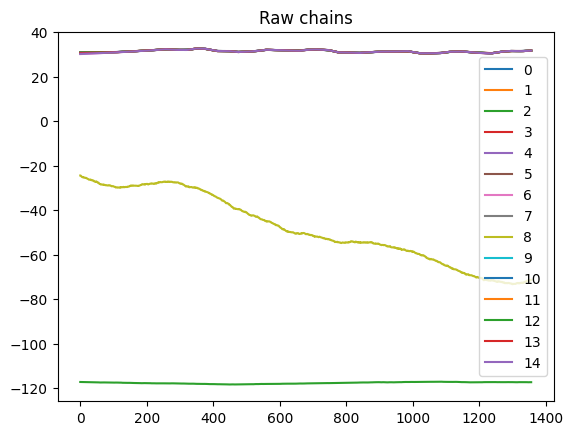

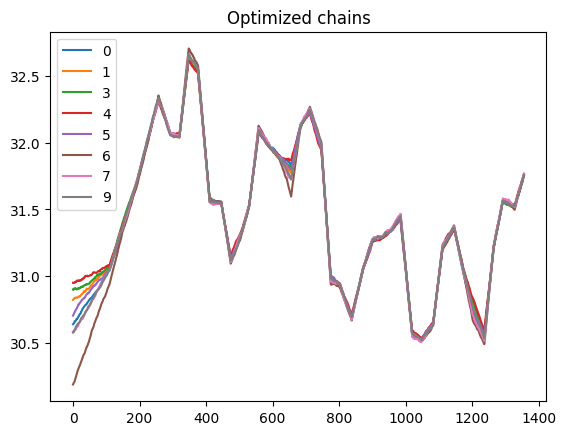

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.113  0.021   0.078    0.152      0.003    0.002      53.0     231.0   
eps    0.276  0.096   0.117    0.455      0.002    0.001    3827.0    7702.0   
p_out  0.142  0.059   0.041    0.252      0.001    0.001    4422.0    7311.0   

       r_hat  
sig     1.11  
eps     1.00  
p_out   1.00  


python3.9(46168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


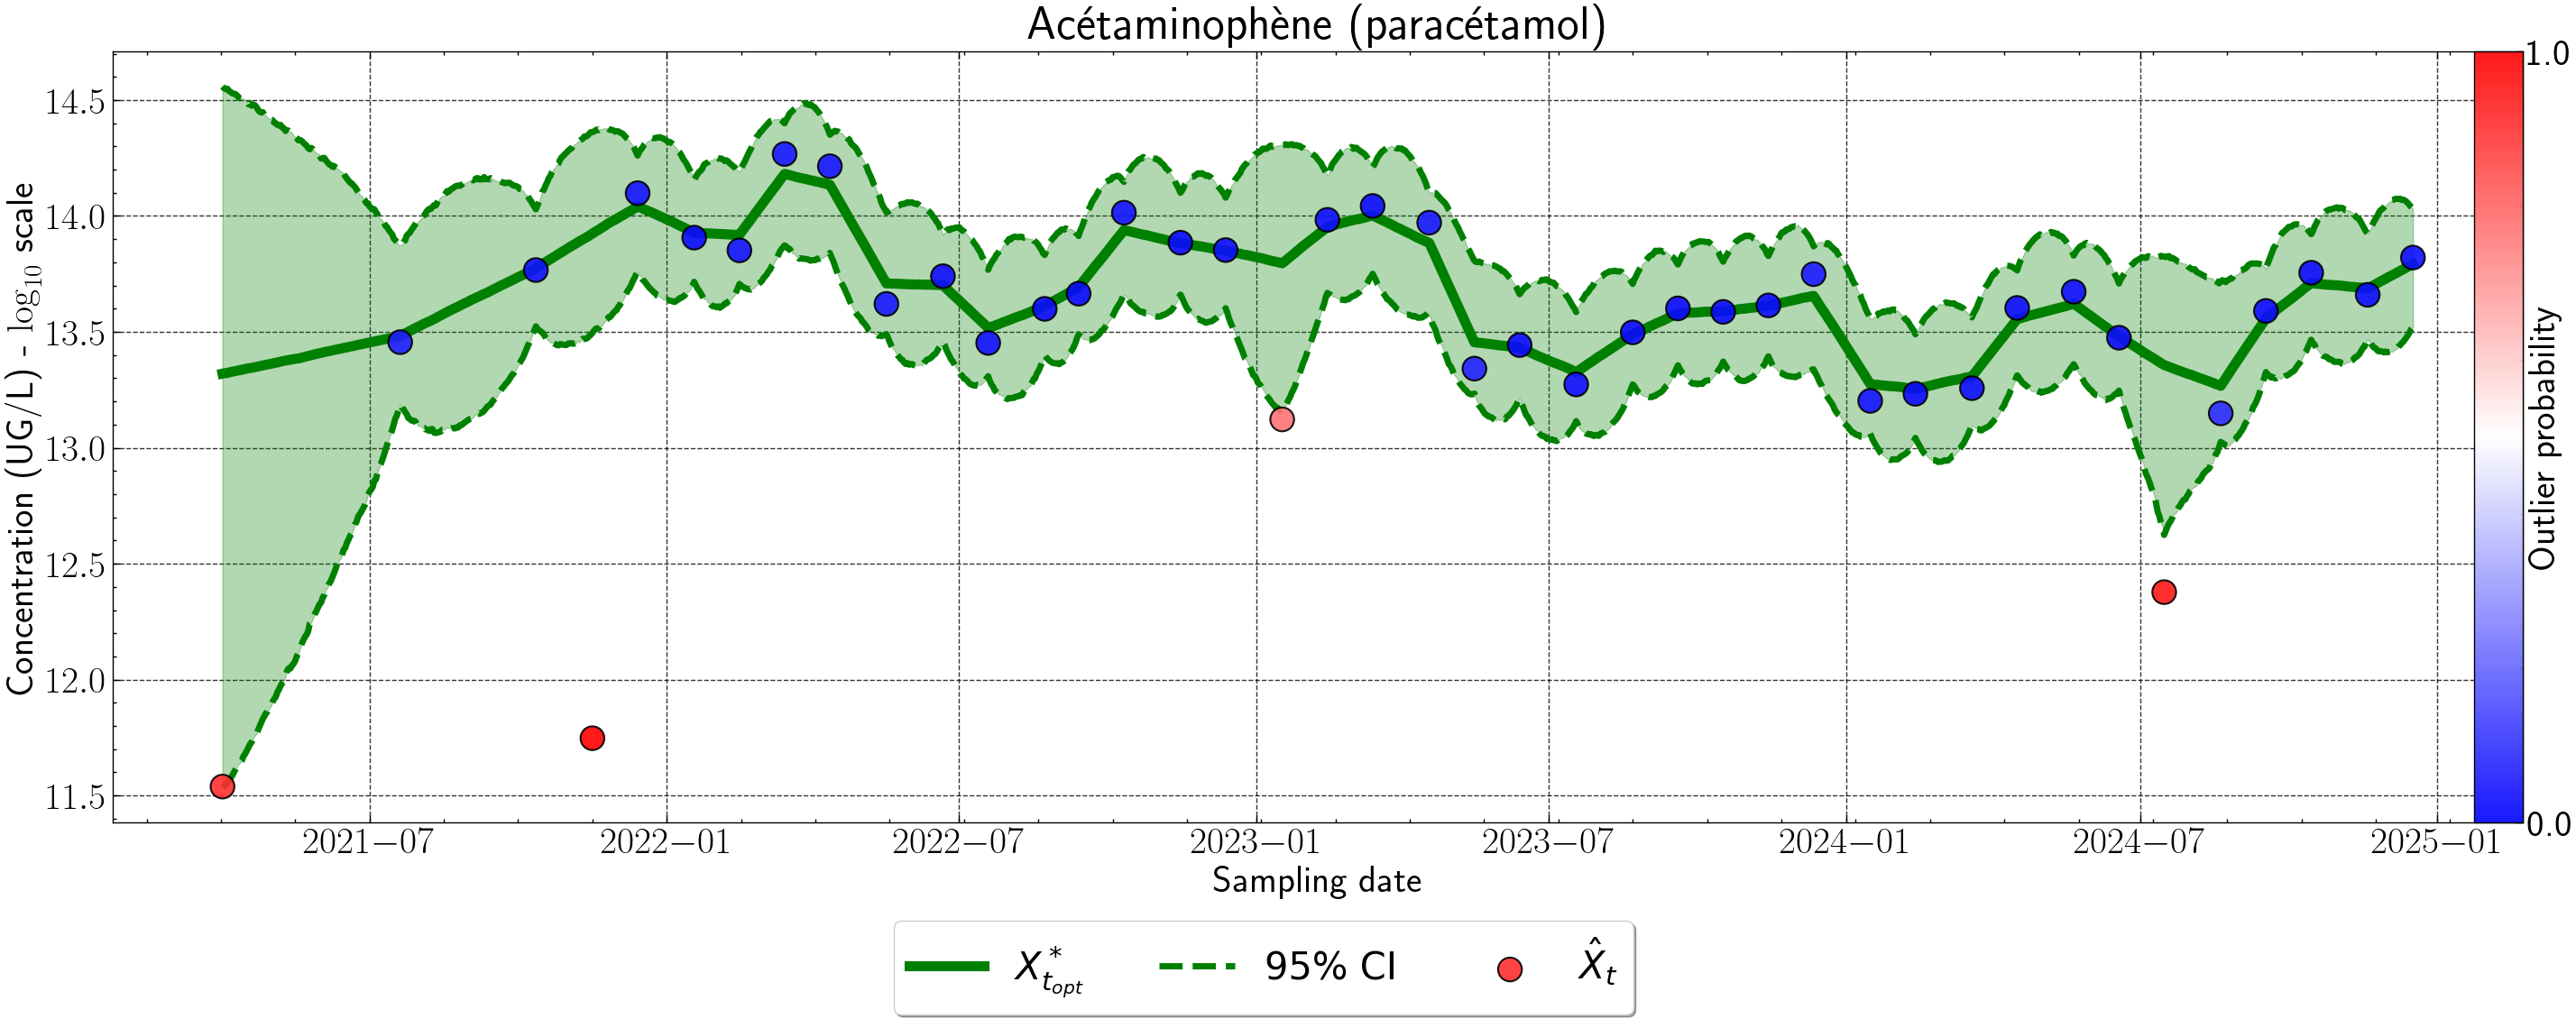

Aténolol


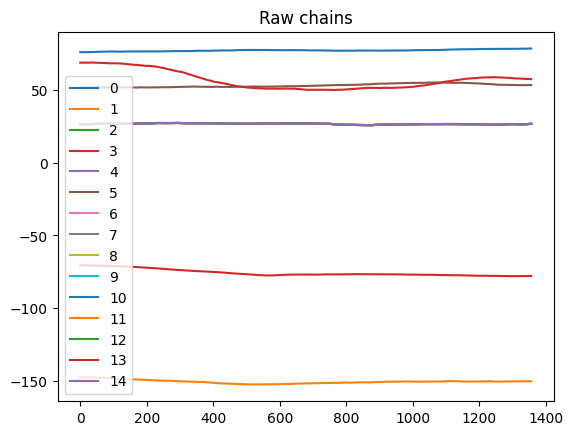

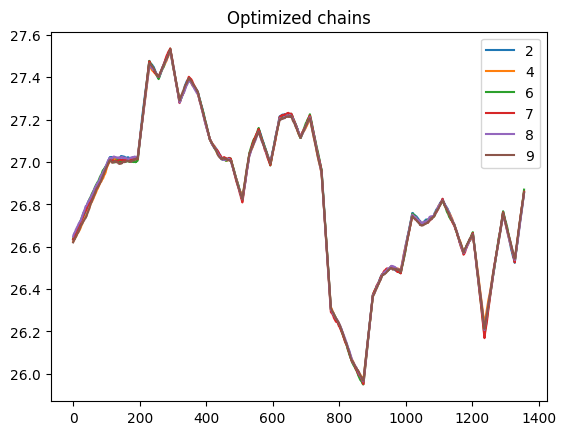

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.071  0.011   0.050    0.091      0.001    0.001      77.0     265.0   
eps    0.199  0.050   0.109    0.293      0.001    0.000    4885.0    8618.0   
p_out  0.071  0.048   0.003    0.158      0.000    0.000    9641.0    7084.0   

       r_hat  
sig     1.07  
eps     1.00  
p_out   1.00  


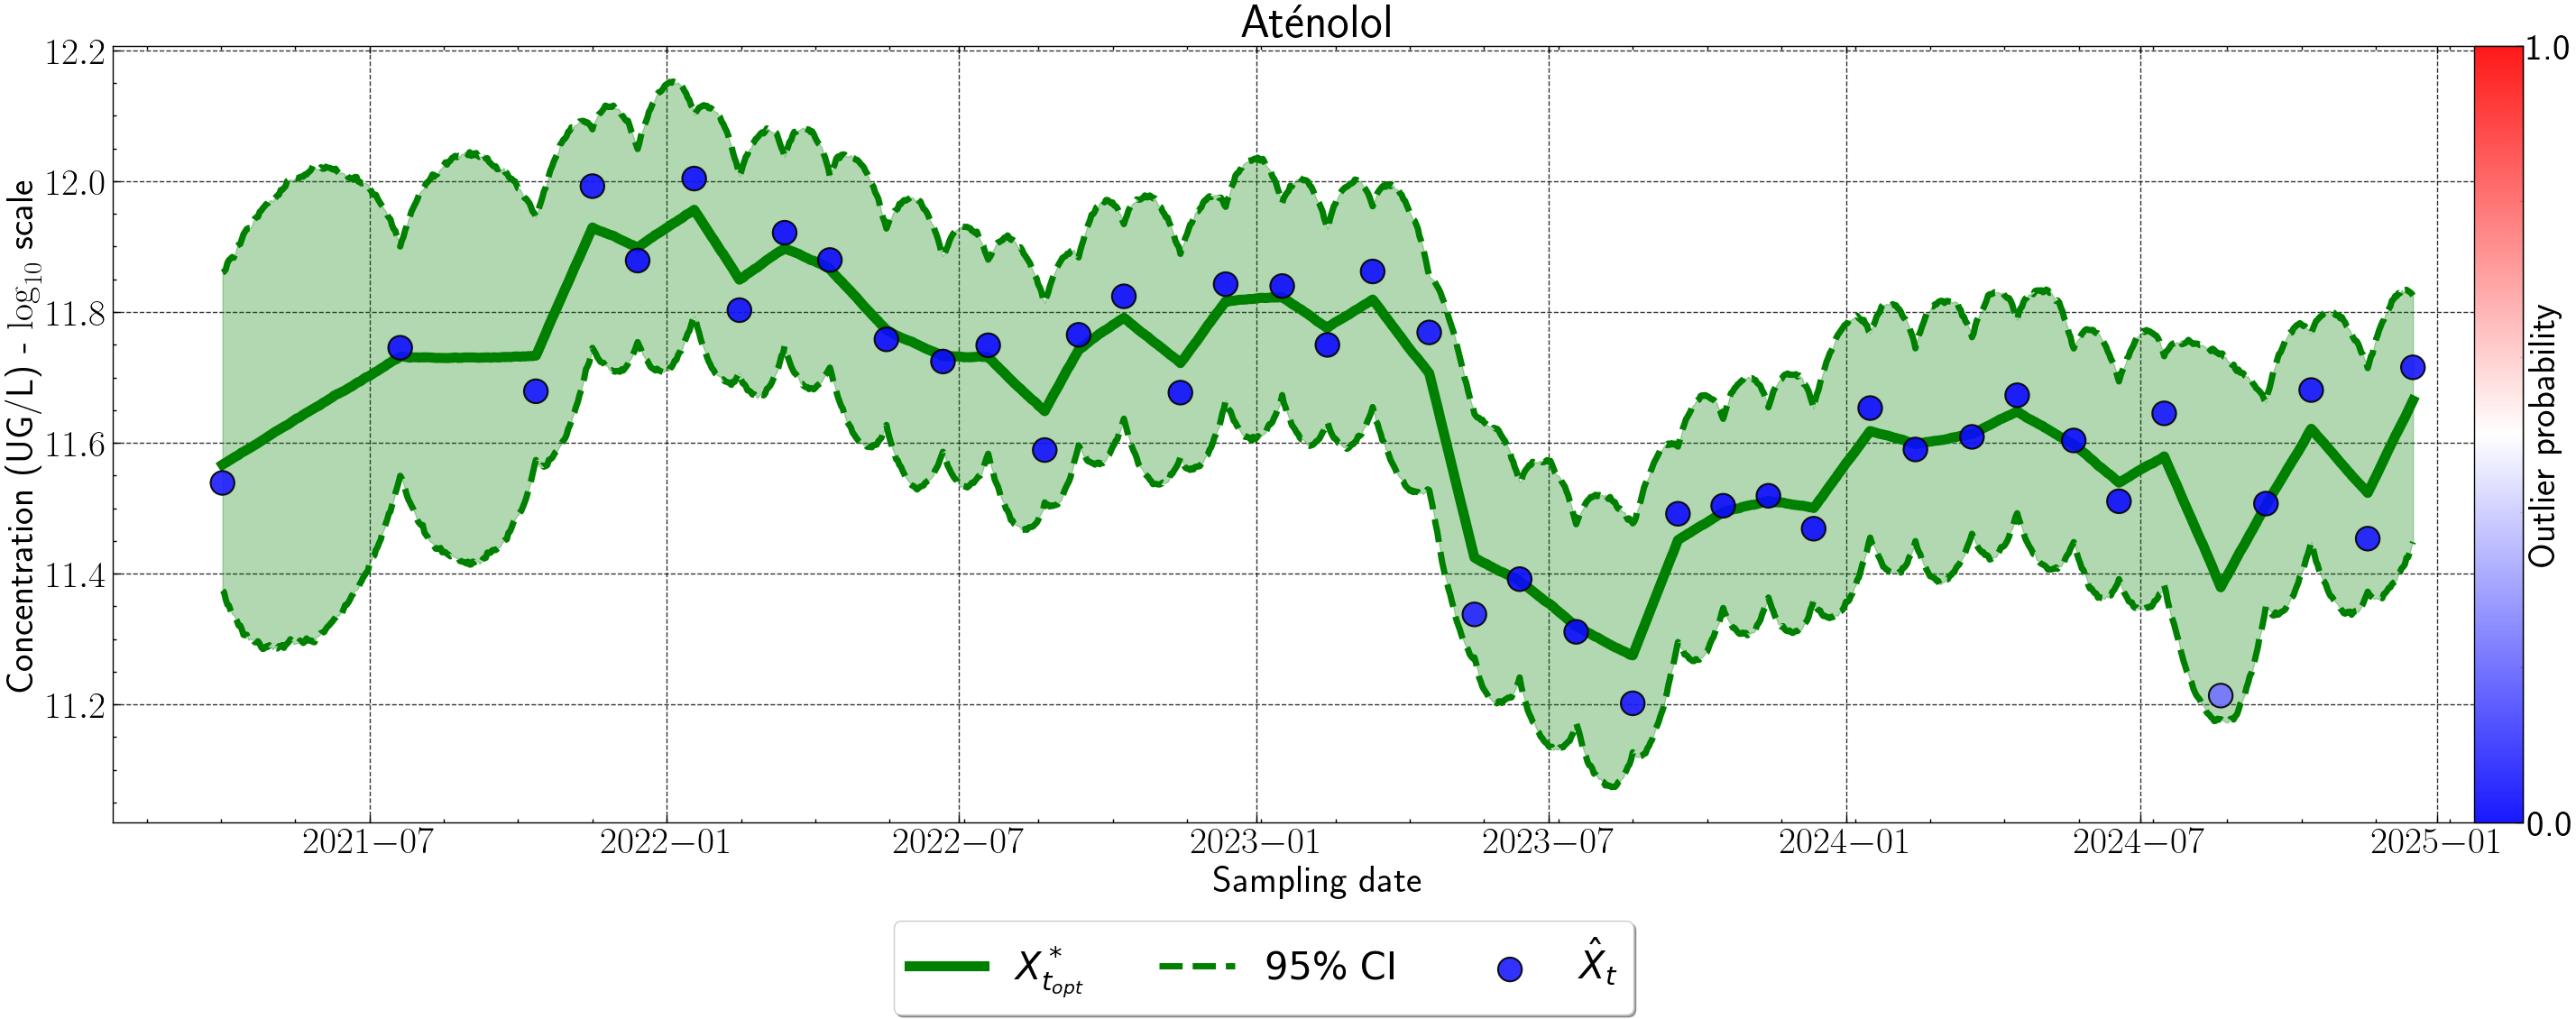

Carbamazépine


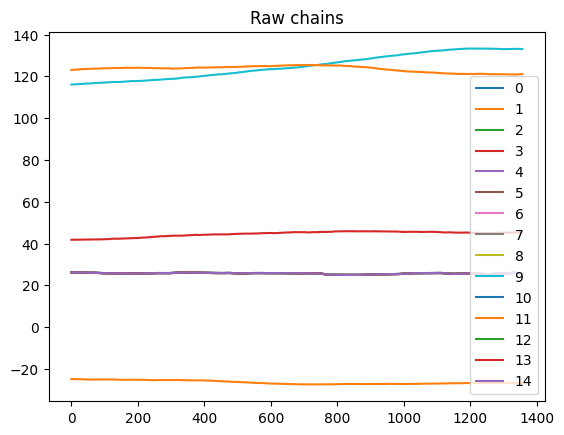

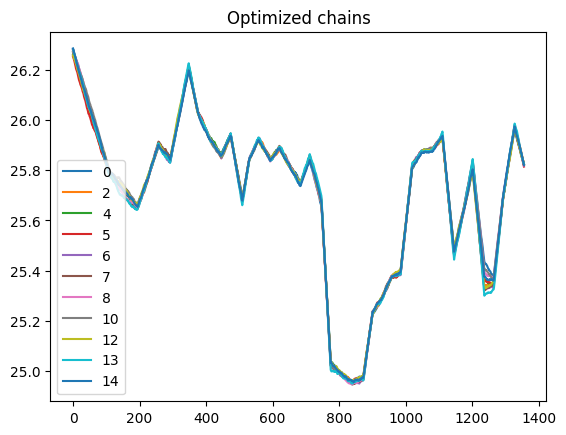

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.072  0.012   0.050    0.096      0.001    0.001     169.0     344.0   
eps    0.192  0.053   0.101    0.291      0.001    0.000    7788.0   13882.0   
p_out  0.091  0.054   0.005    0.187      0.000    0.000   15152.0   13626.0   

       r_hat  
sig     1.05  
eps     1.00  
p_out   1.00  


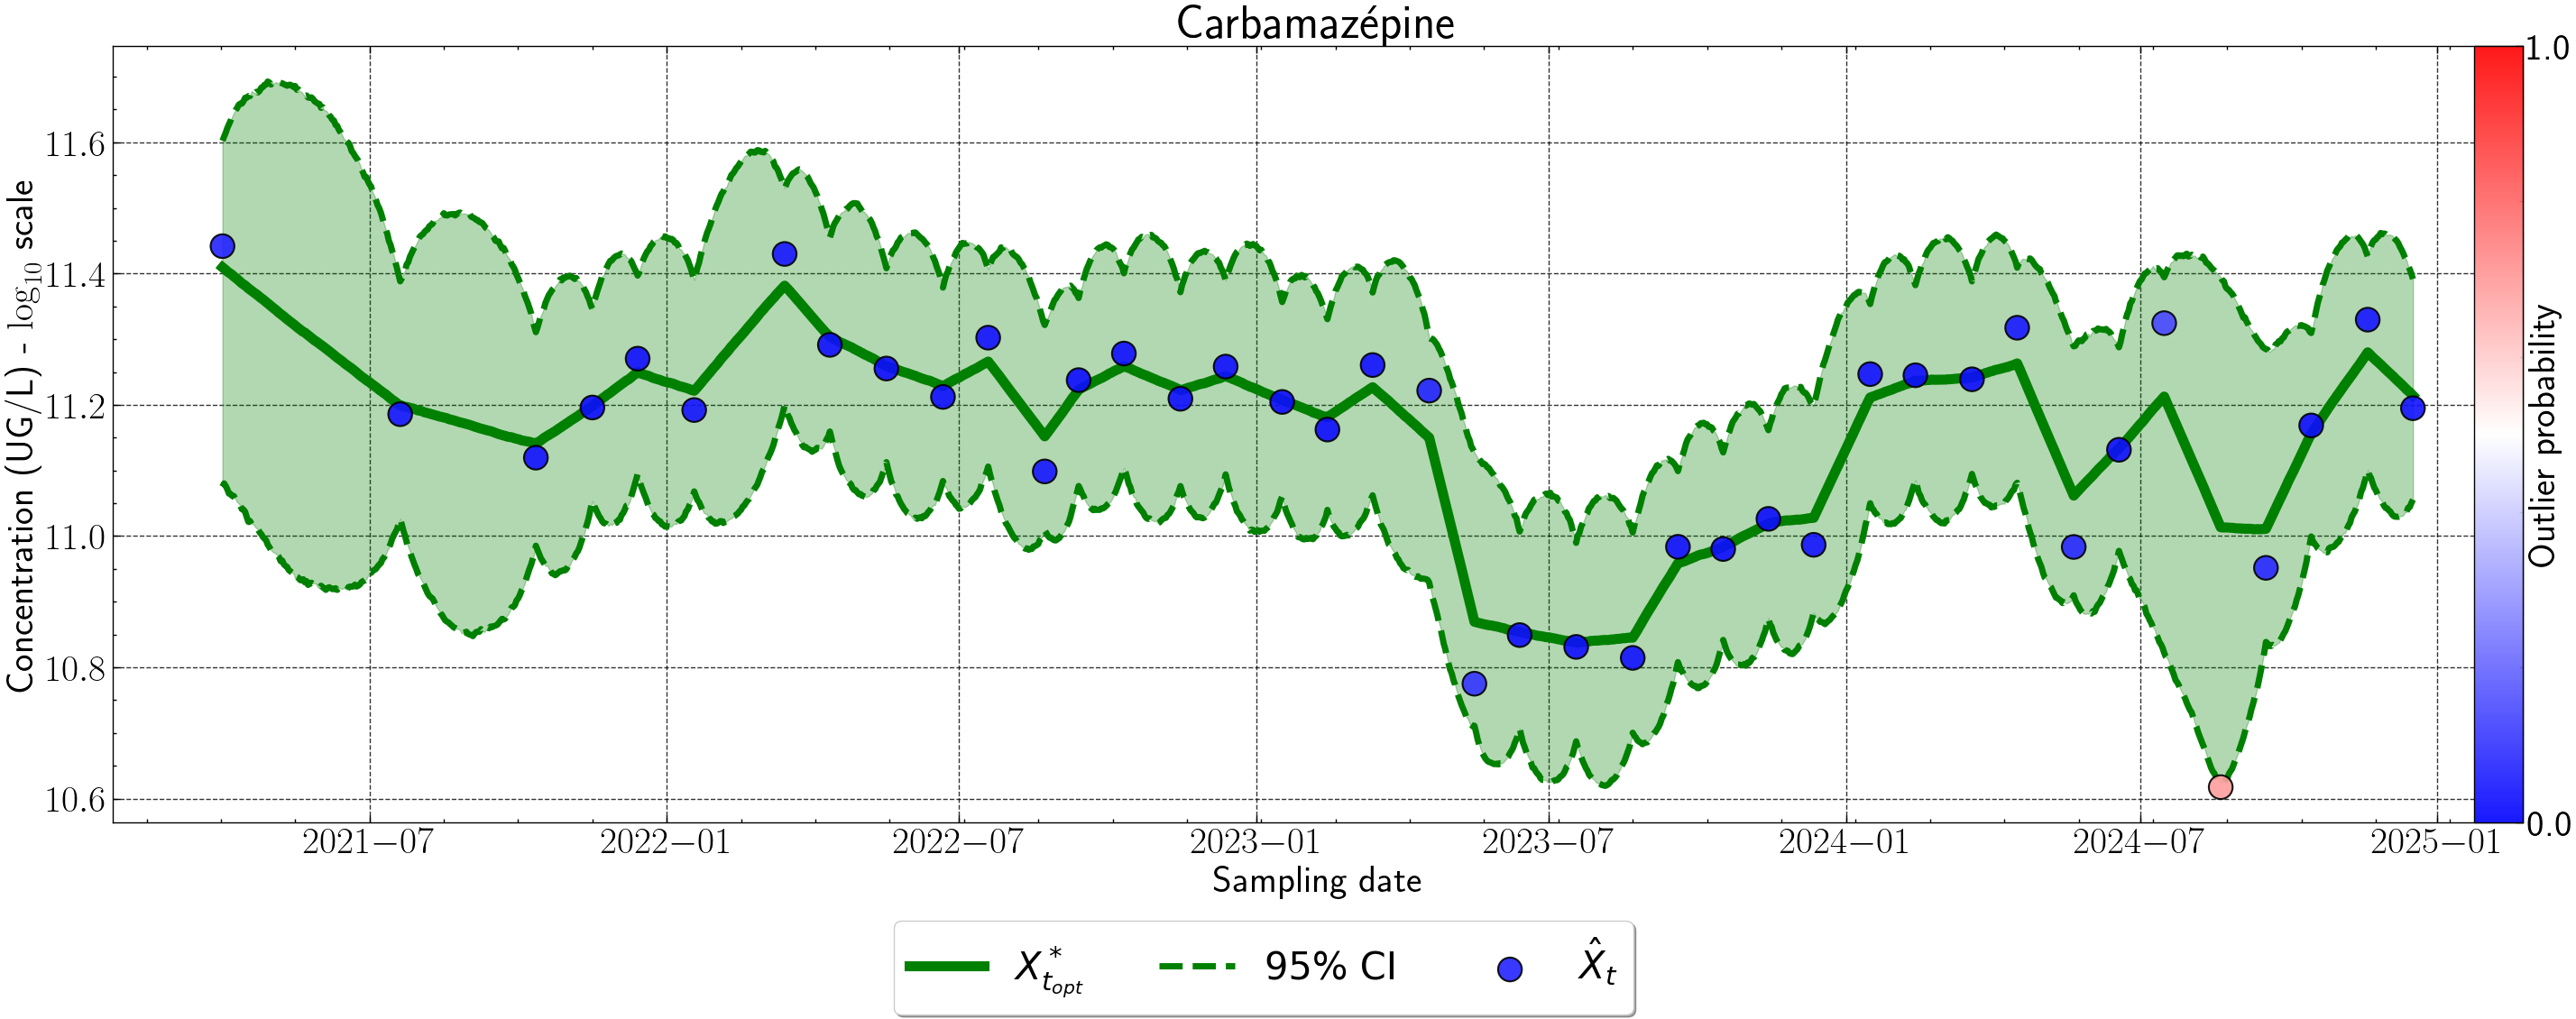

Ciprofloxacine


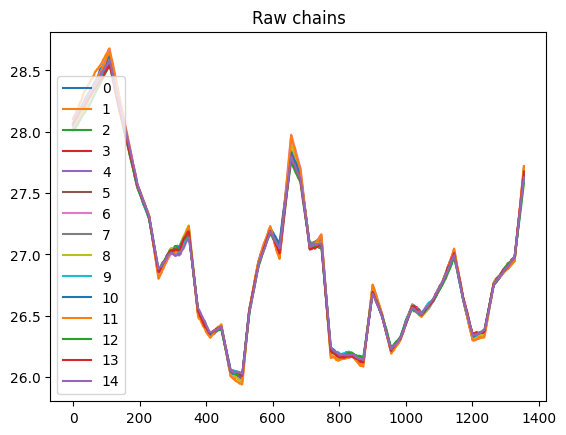

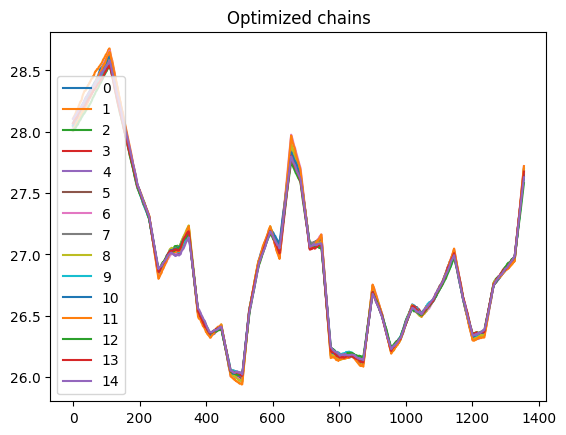

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.117  0.024   0.074    0.164      0.003    0.002      73.0     311.0   
eps    0.335  0.115   0.133    0.545      0.003    0.002    2060.0   13061.0   
p_out  0.120  0.063   0.015    0.235      0.000    0.000   19648.0   20839.0   

       r_hat  
sig     1.16  
eps     1.01  
p_out   1.00  


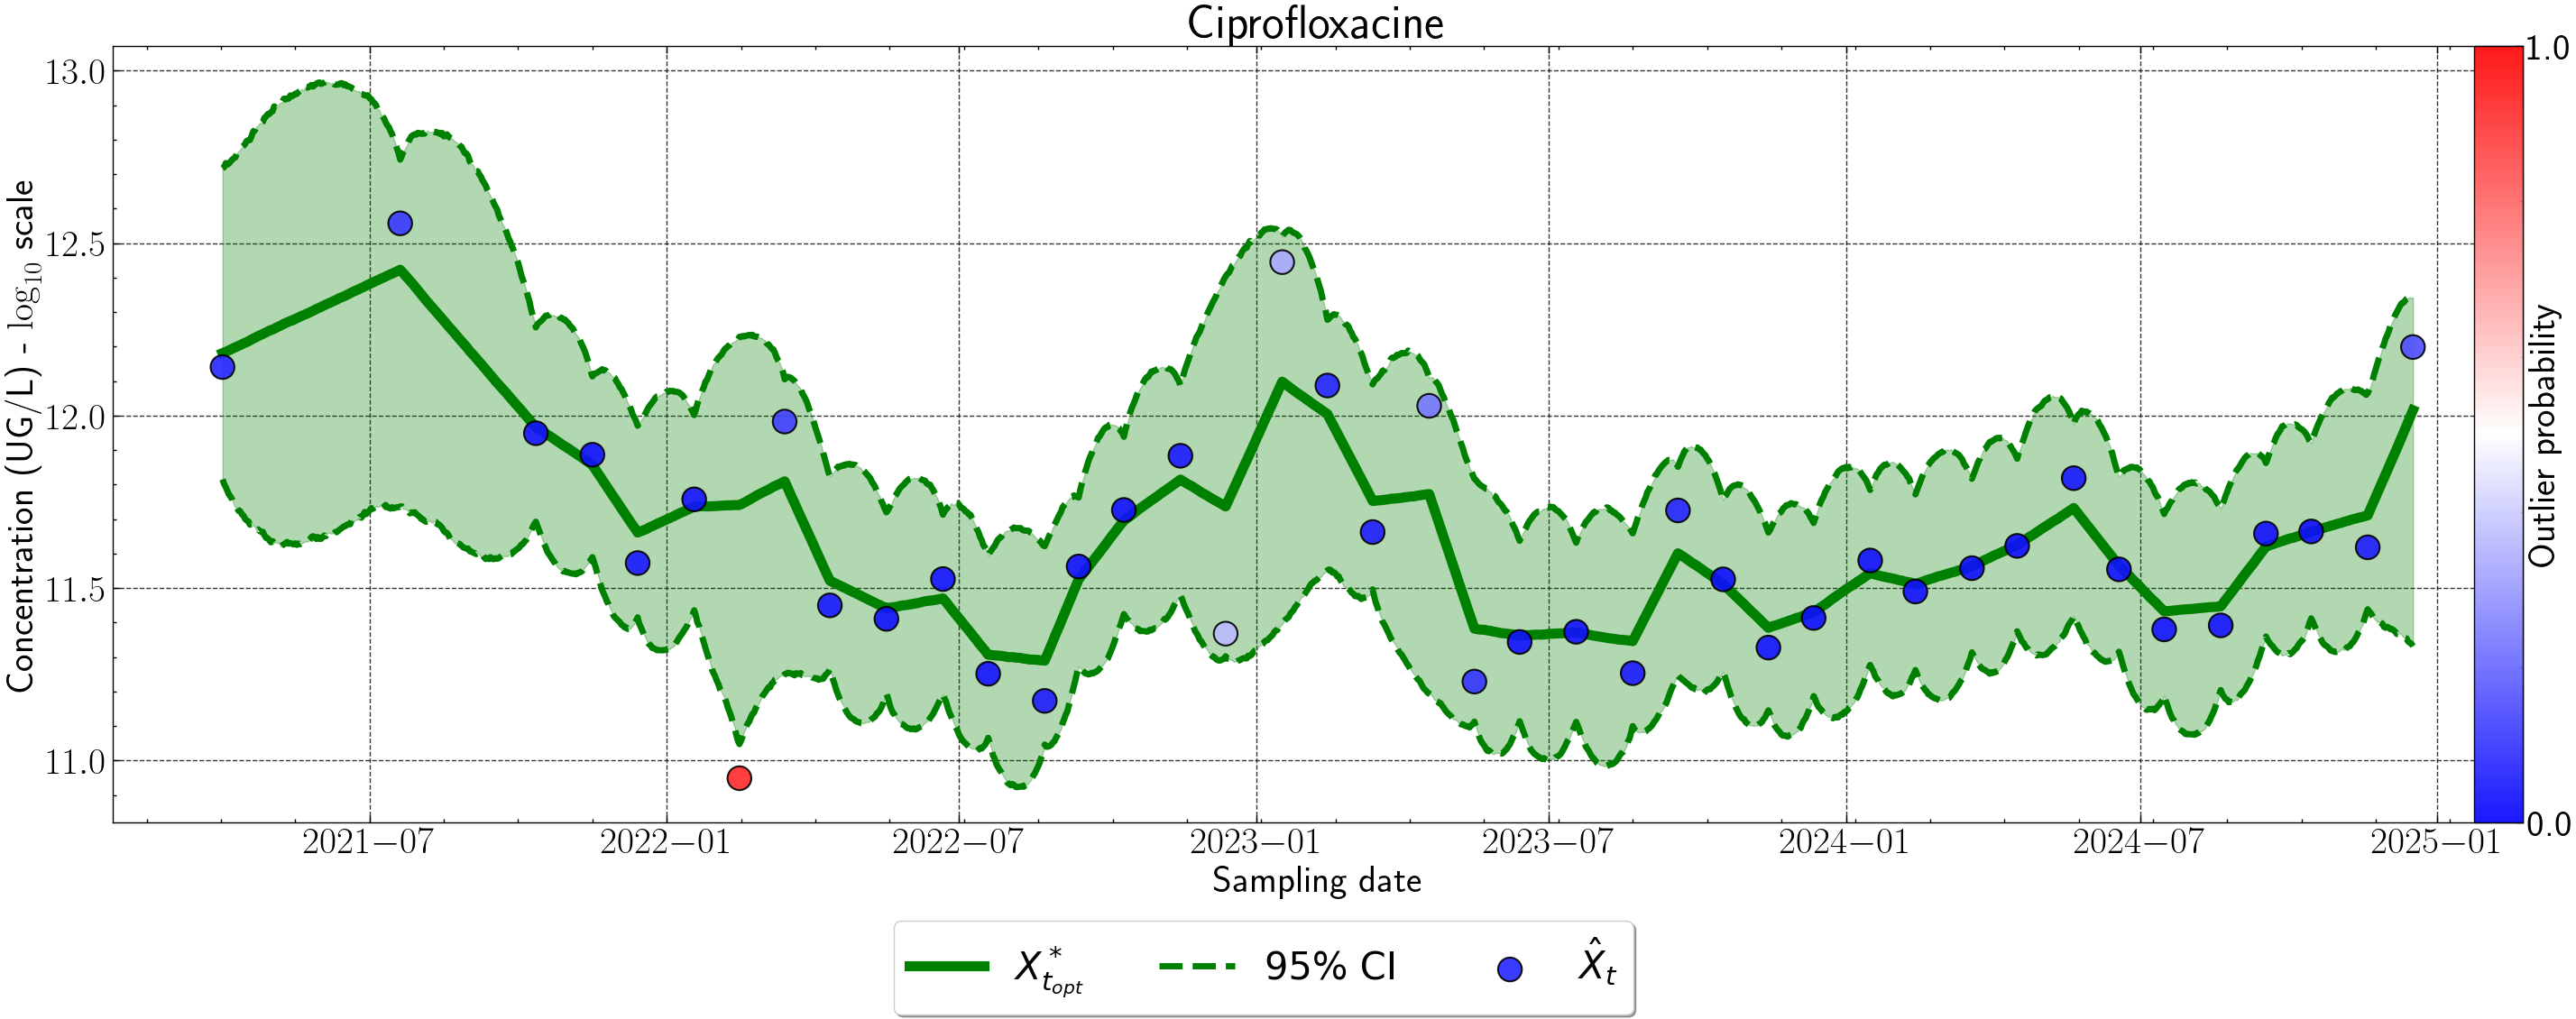

Diclofénac


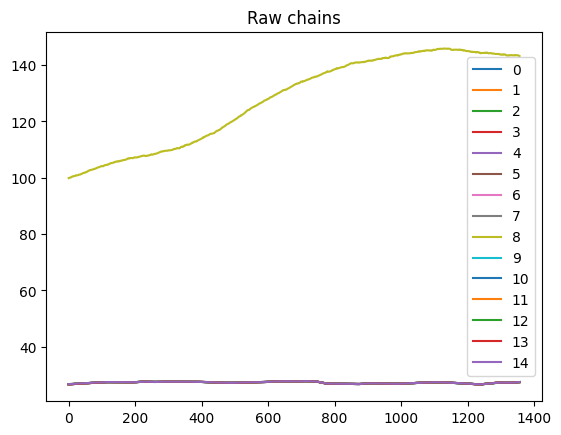

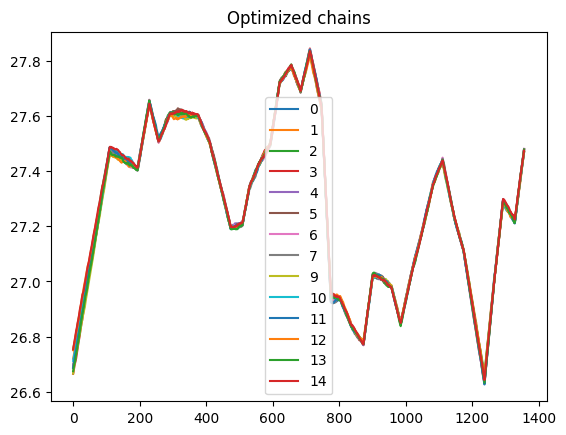

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.067  0.010   0.048    0.088      0.001    0.001     182.0     529.0   
eps    0.170  0.045   0.090    0.254      0.000    0.000   10830.0   17986.0   
p_out  0.126  0.053   0.036    0.224      0.000    0.000   23813.0   16676.0   

       r_hat  
sig     1.06  
eps     1.00  
p_out   1.00  


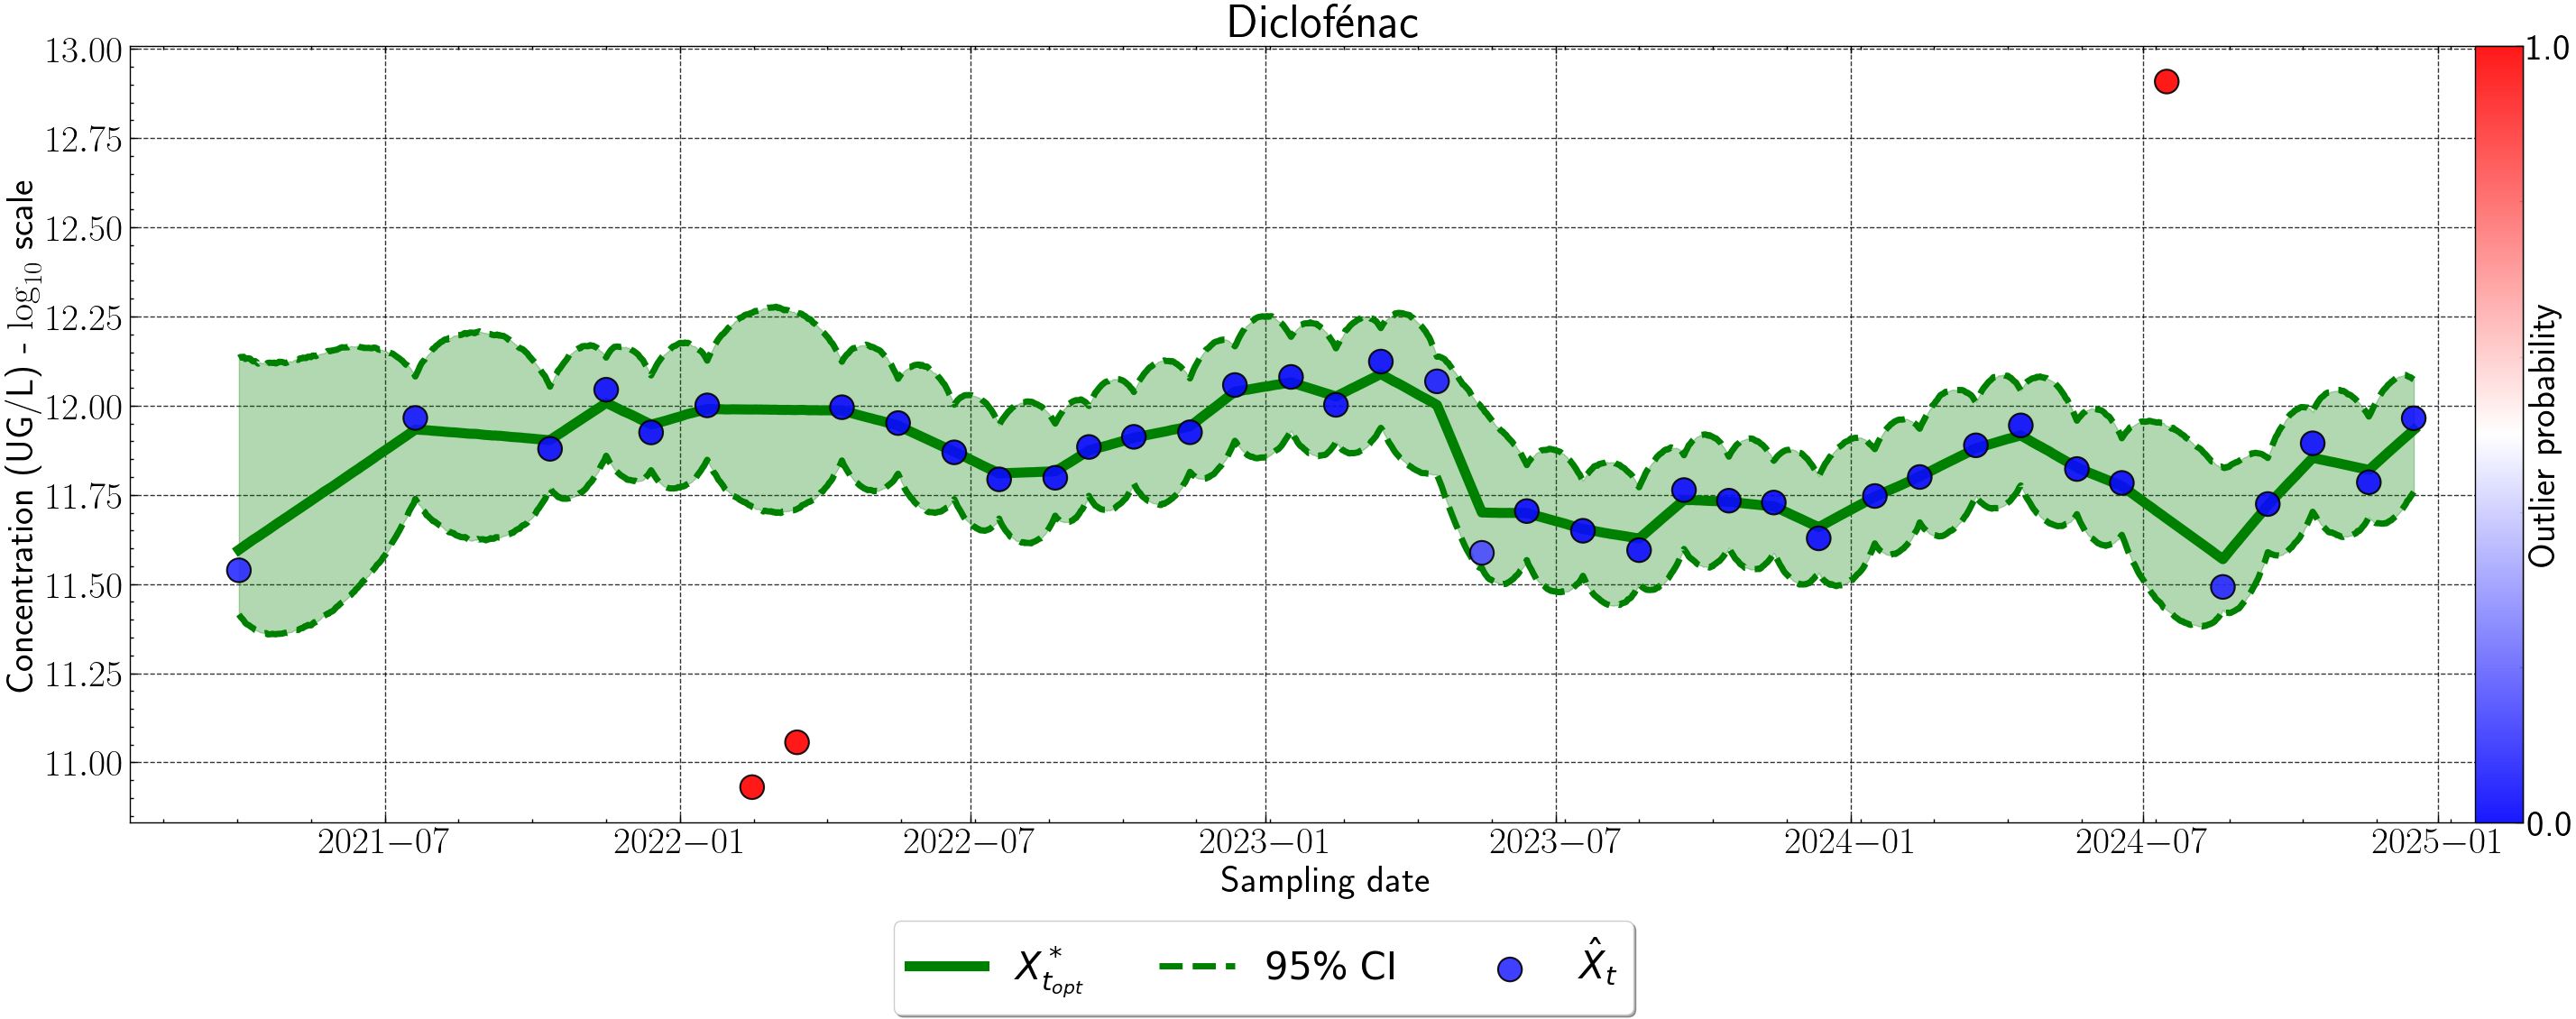

Erythromycine A


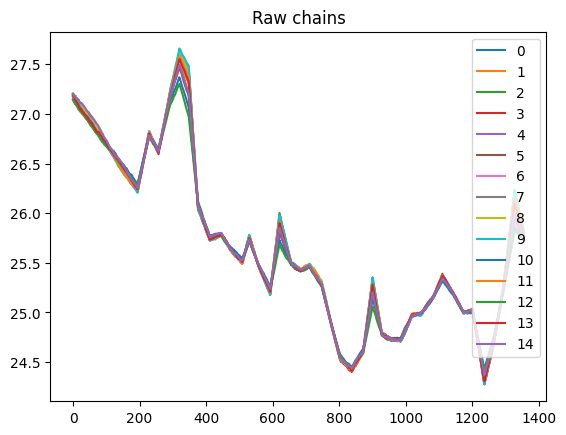

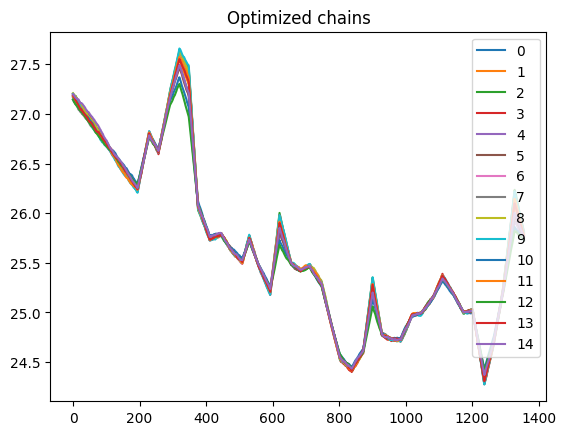

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.120  0.026   0.074    0.168      0.003    0.002      63.0     149.0   
eps    0.359  0.126   0.144    0.596      0.002    0.001    4653.0   13009.0   
p_out  0.098  0.063   0.003    0.211      0.002    0.001    1575.0    6198.0   

       r_hat  
sig     1.17  
eps     1.00  
p_out   1.01  


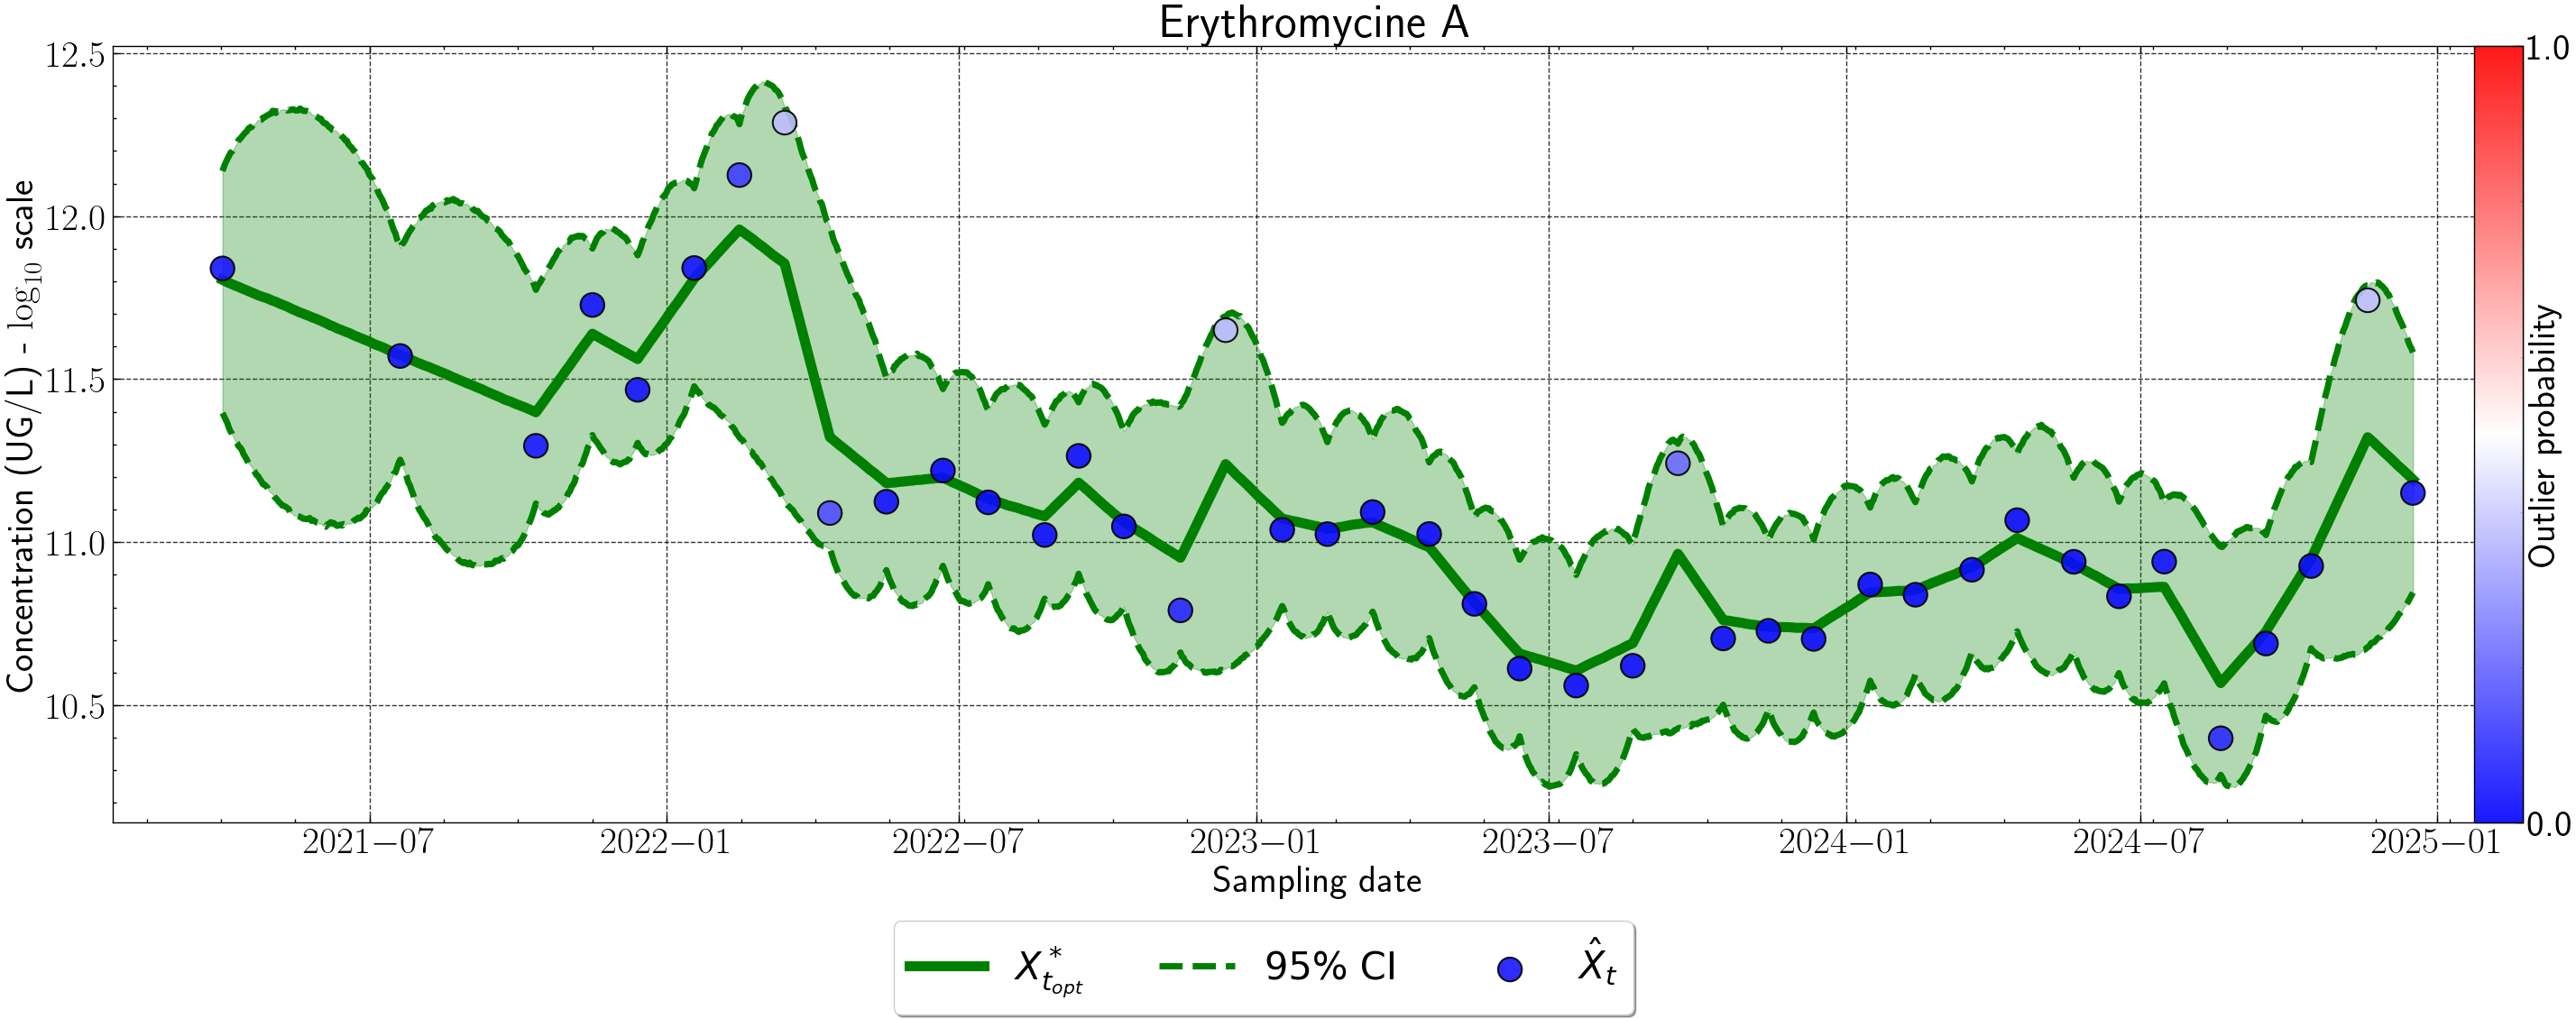

Ibuprofène


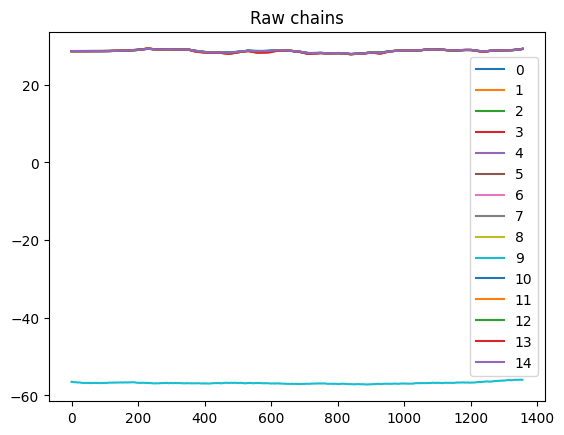

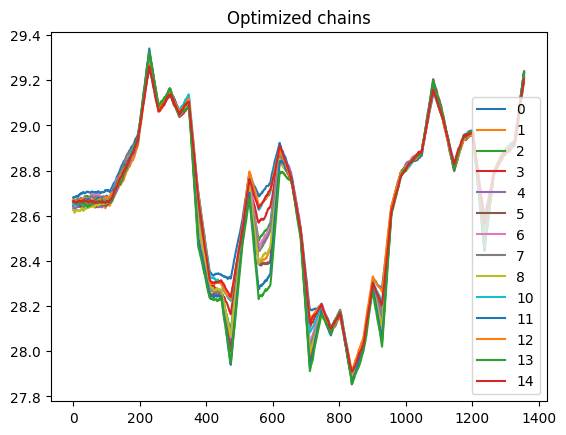

Best chain combination summary:
       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.10  0.024   0.059    0.146      0.004    0.003      48.0     144.0   
eps    0.33  0.130   0.122    0.577      0.002    0.001    4176.0   13716.0   
p_out  0.17  0.082   0.022    0.317      0.003    0.002     757.0    9865.0   

       r_hat  
sig     1.23  
eps     1.00  
p_out   1.02  


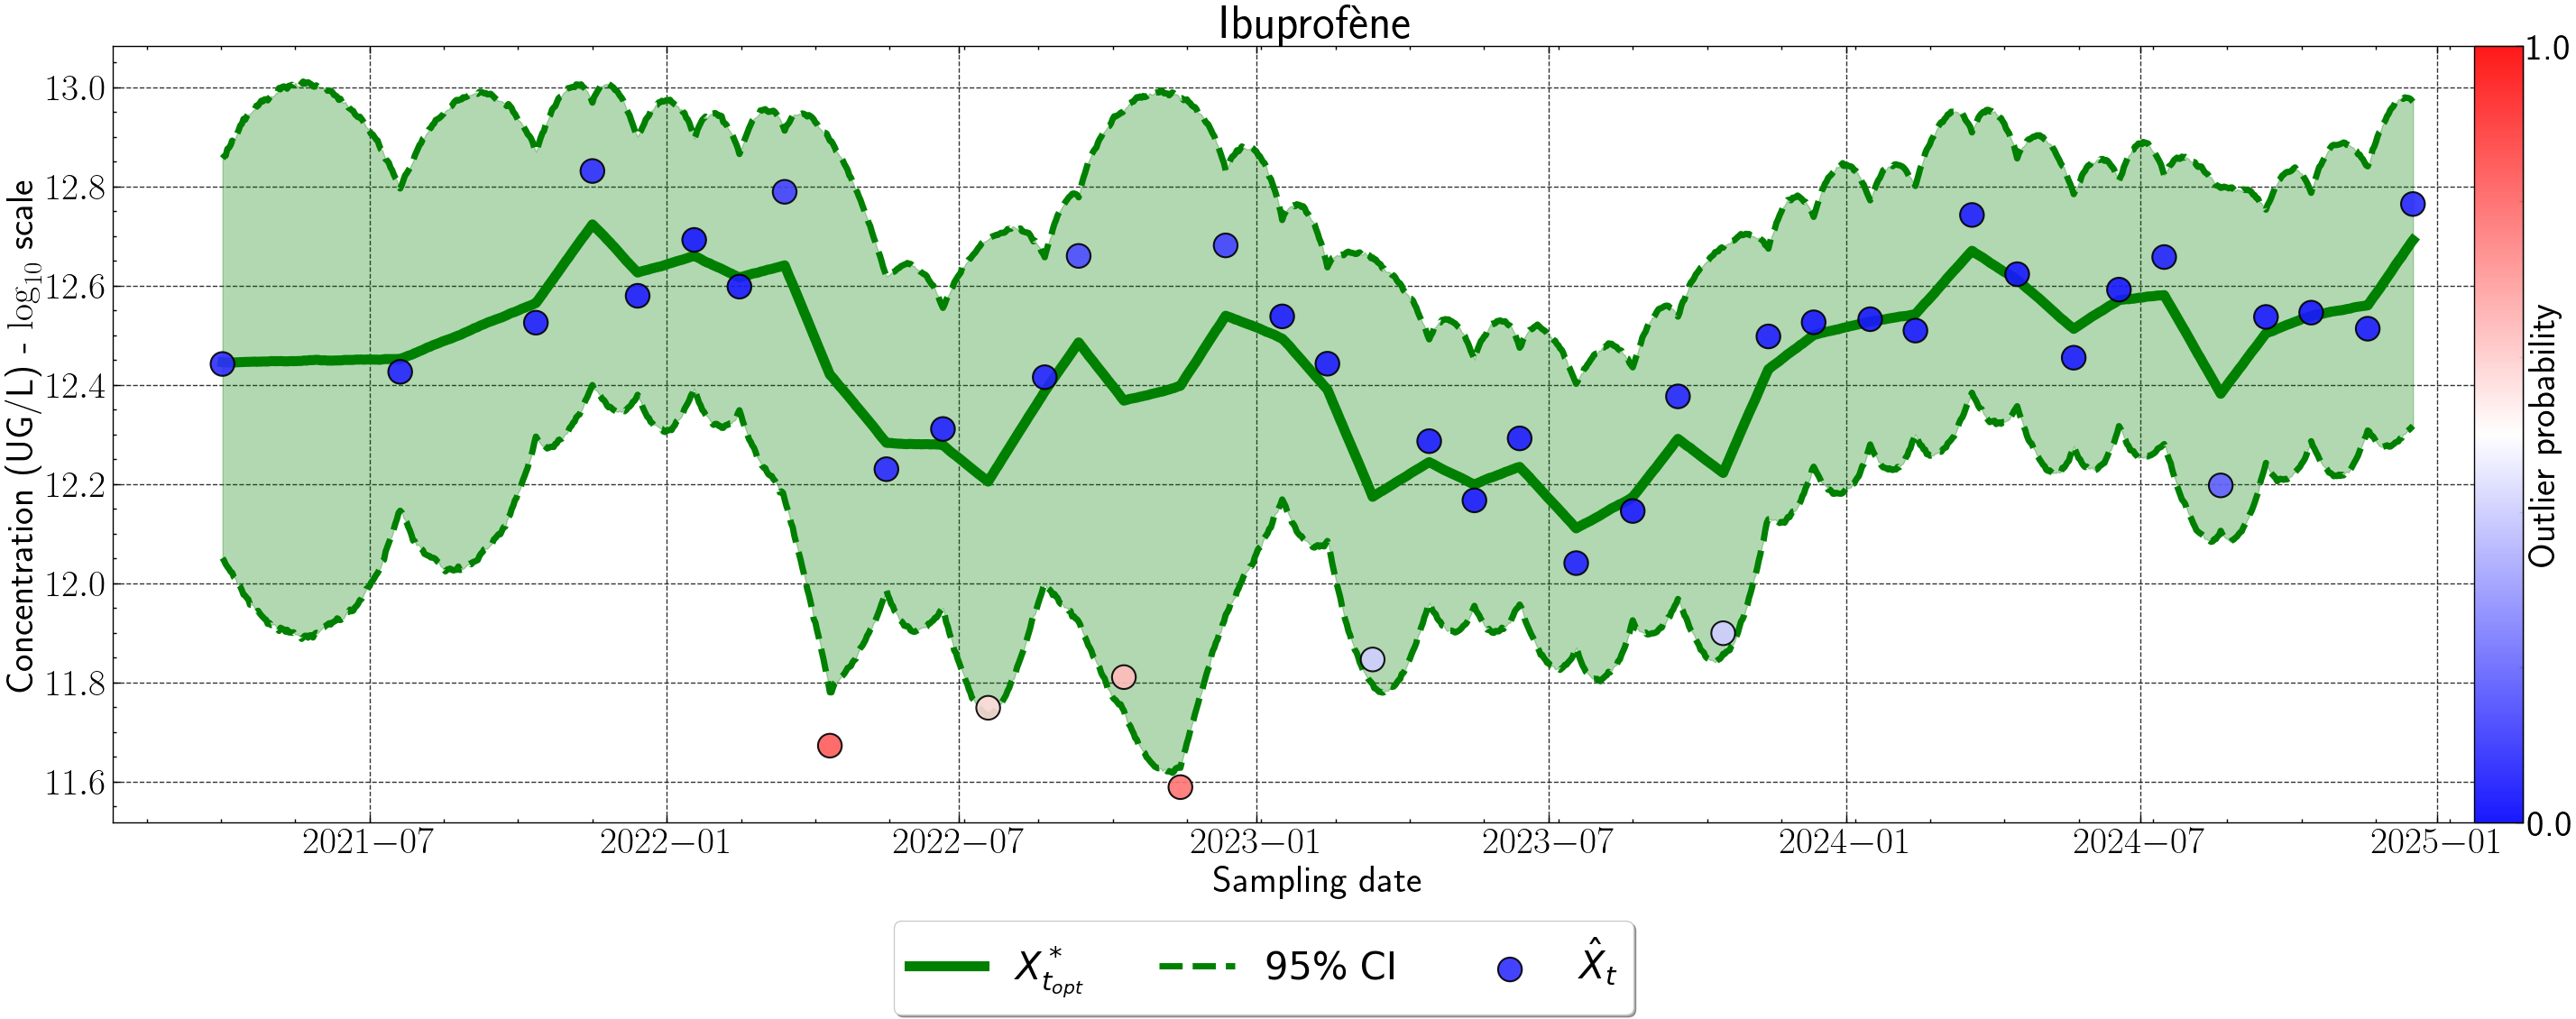

Kétoprofène


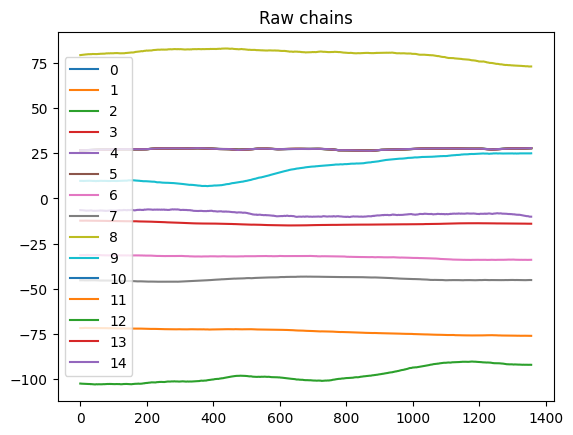

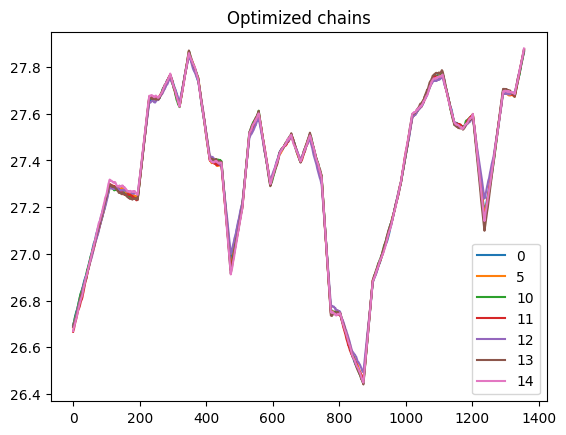

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.074  0.013   0.050    0.097      0.002    0.001      69.0     193.0   
eps    0.206  0.055   0.109    0.309      0.001    0.001    4914.0    9643.0   
p_out  0.085  0.055   0.004    0.188      0.001    0.000    8481.0    8996.0   

       r_hat  
sig      1.1  
eps      1.0  
p_out    1.0  


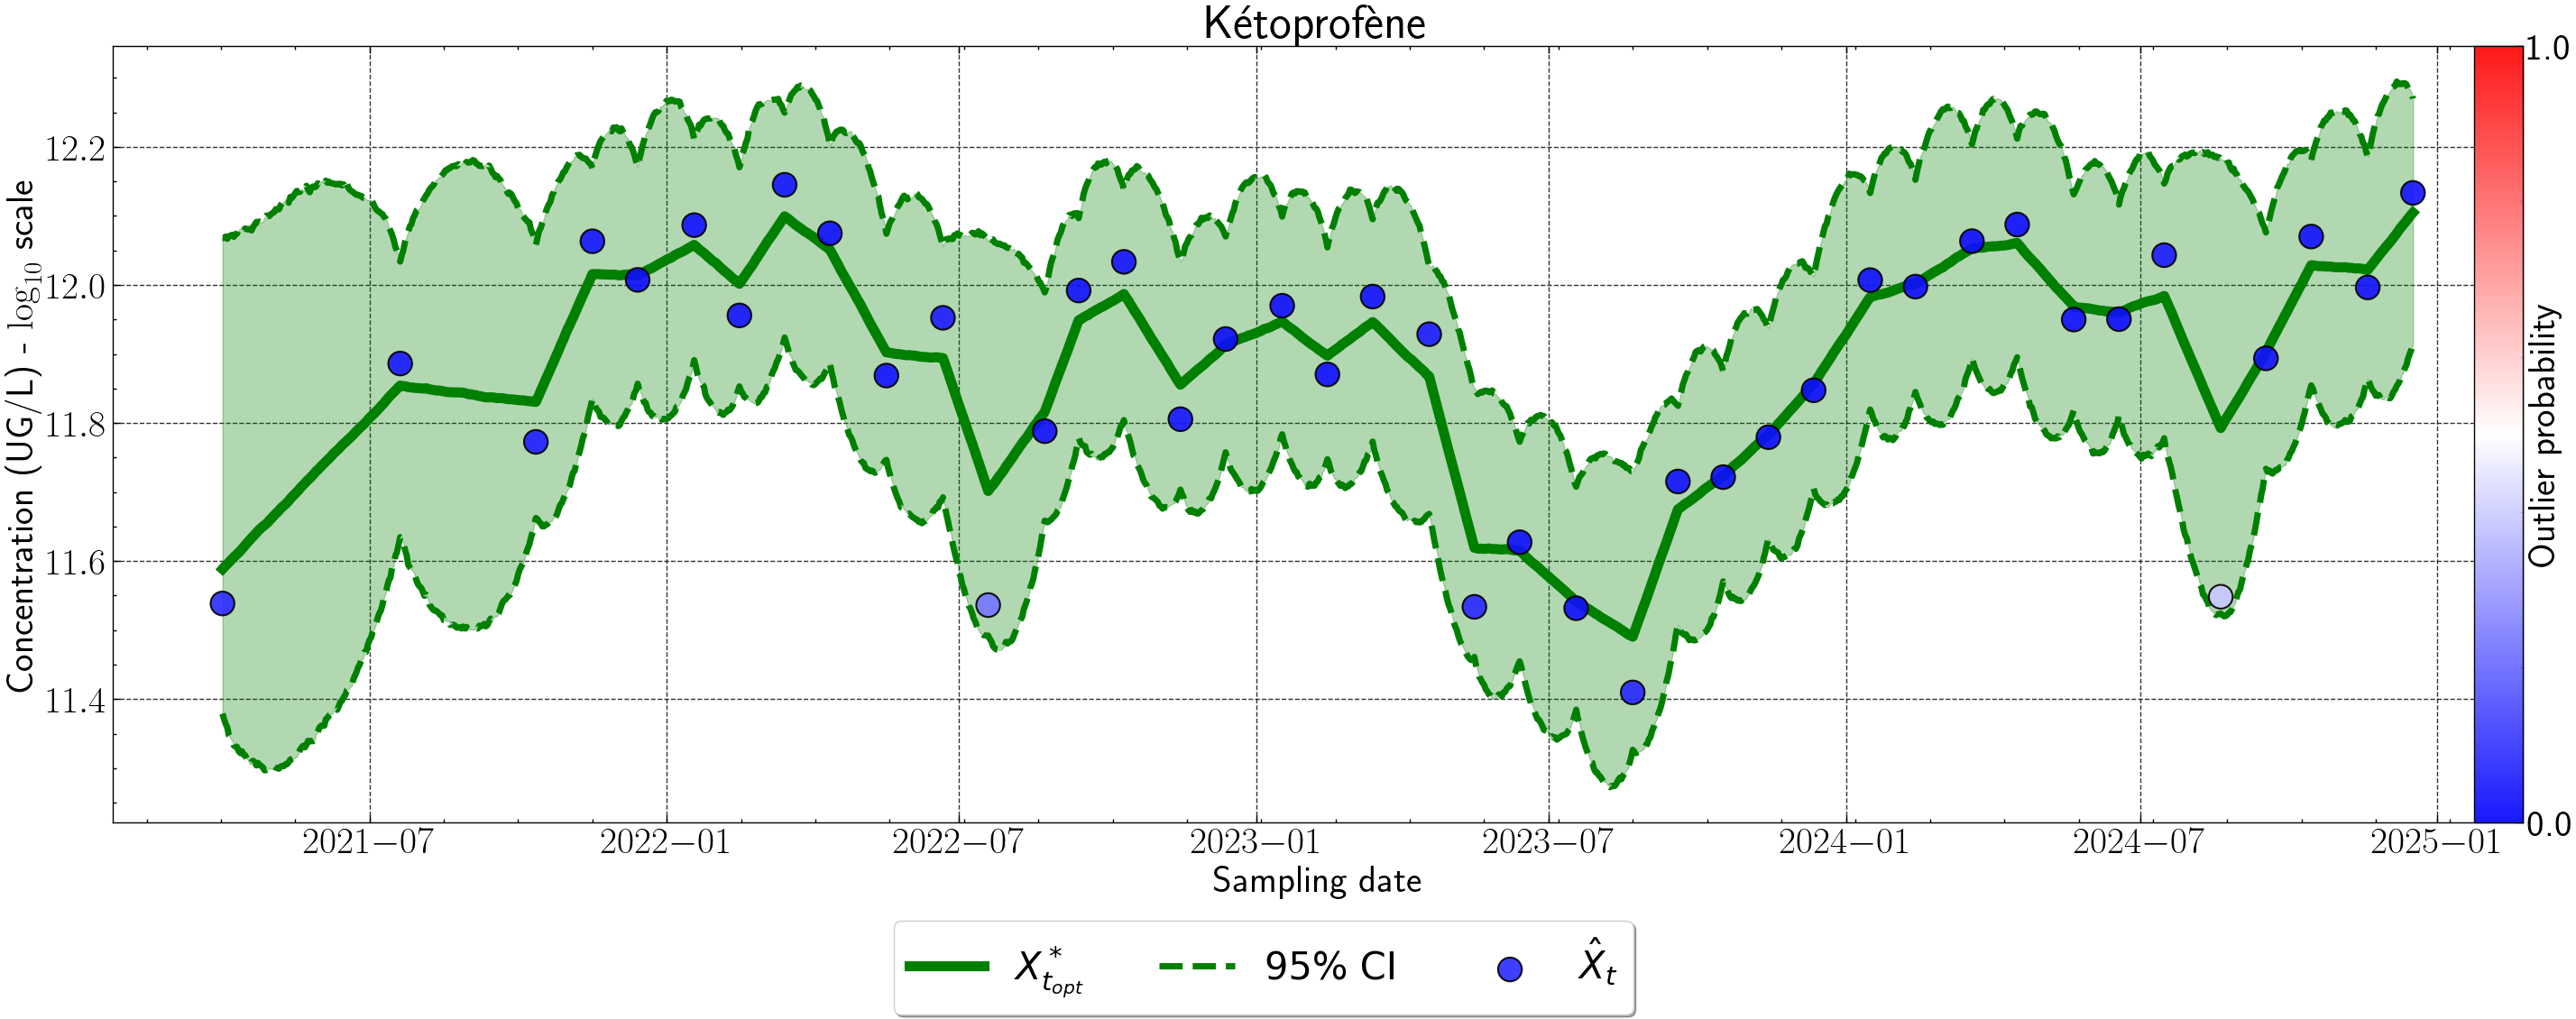

Naproxène


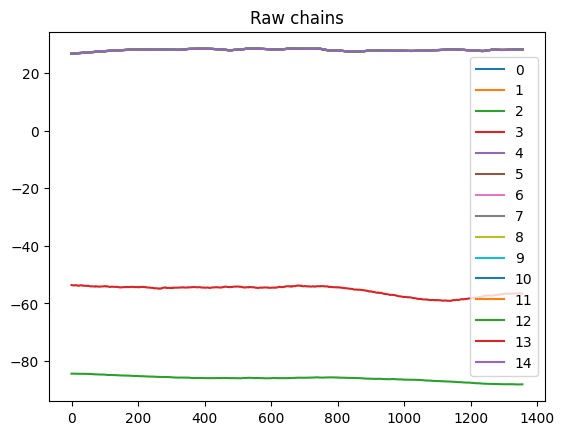

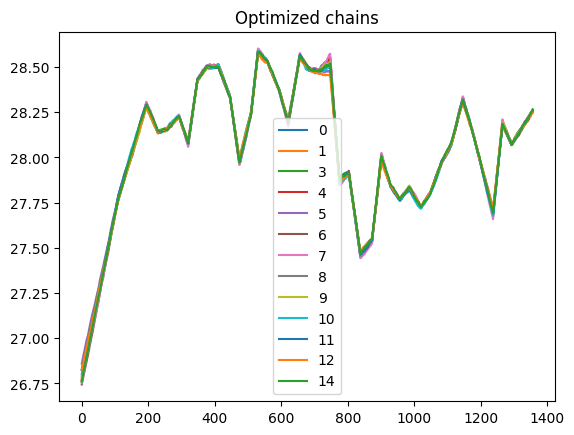

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.080  0.013   0.056    0.106      0.001    0.001     130.0     233.0   
eps    0.230  0.063   0.116    0.345      0.001    0.001    6308.0   16194.0   
p_out  0.079  0.051   0.003    0.171      0.000    0.000   16327.0   17353.0   

       r_hat  
sig     1.08  
eps     1.00  
p_out   1.00  


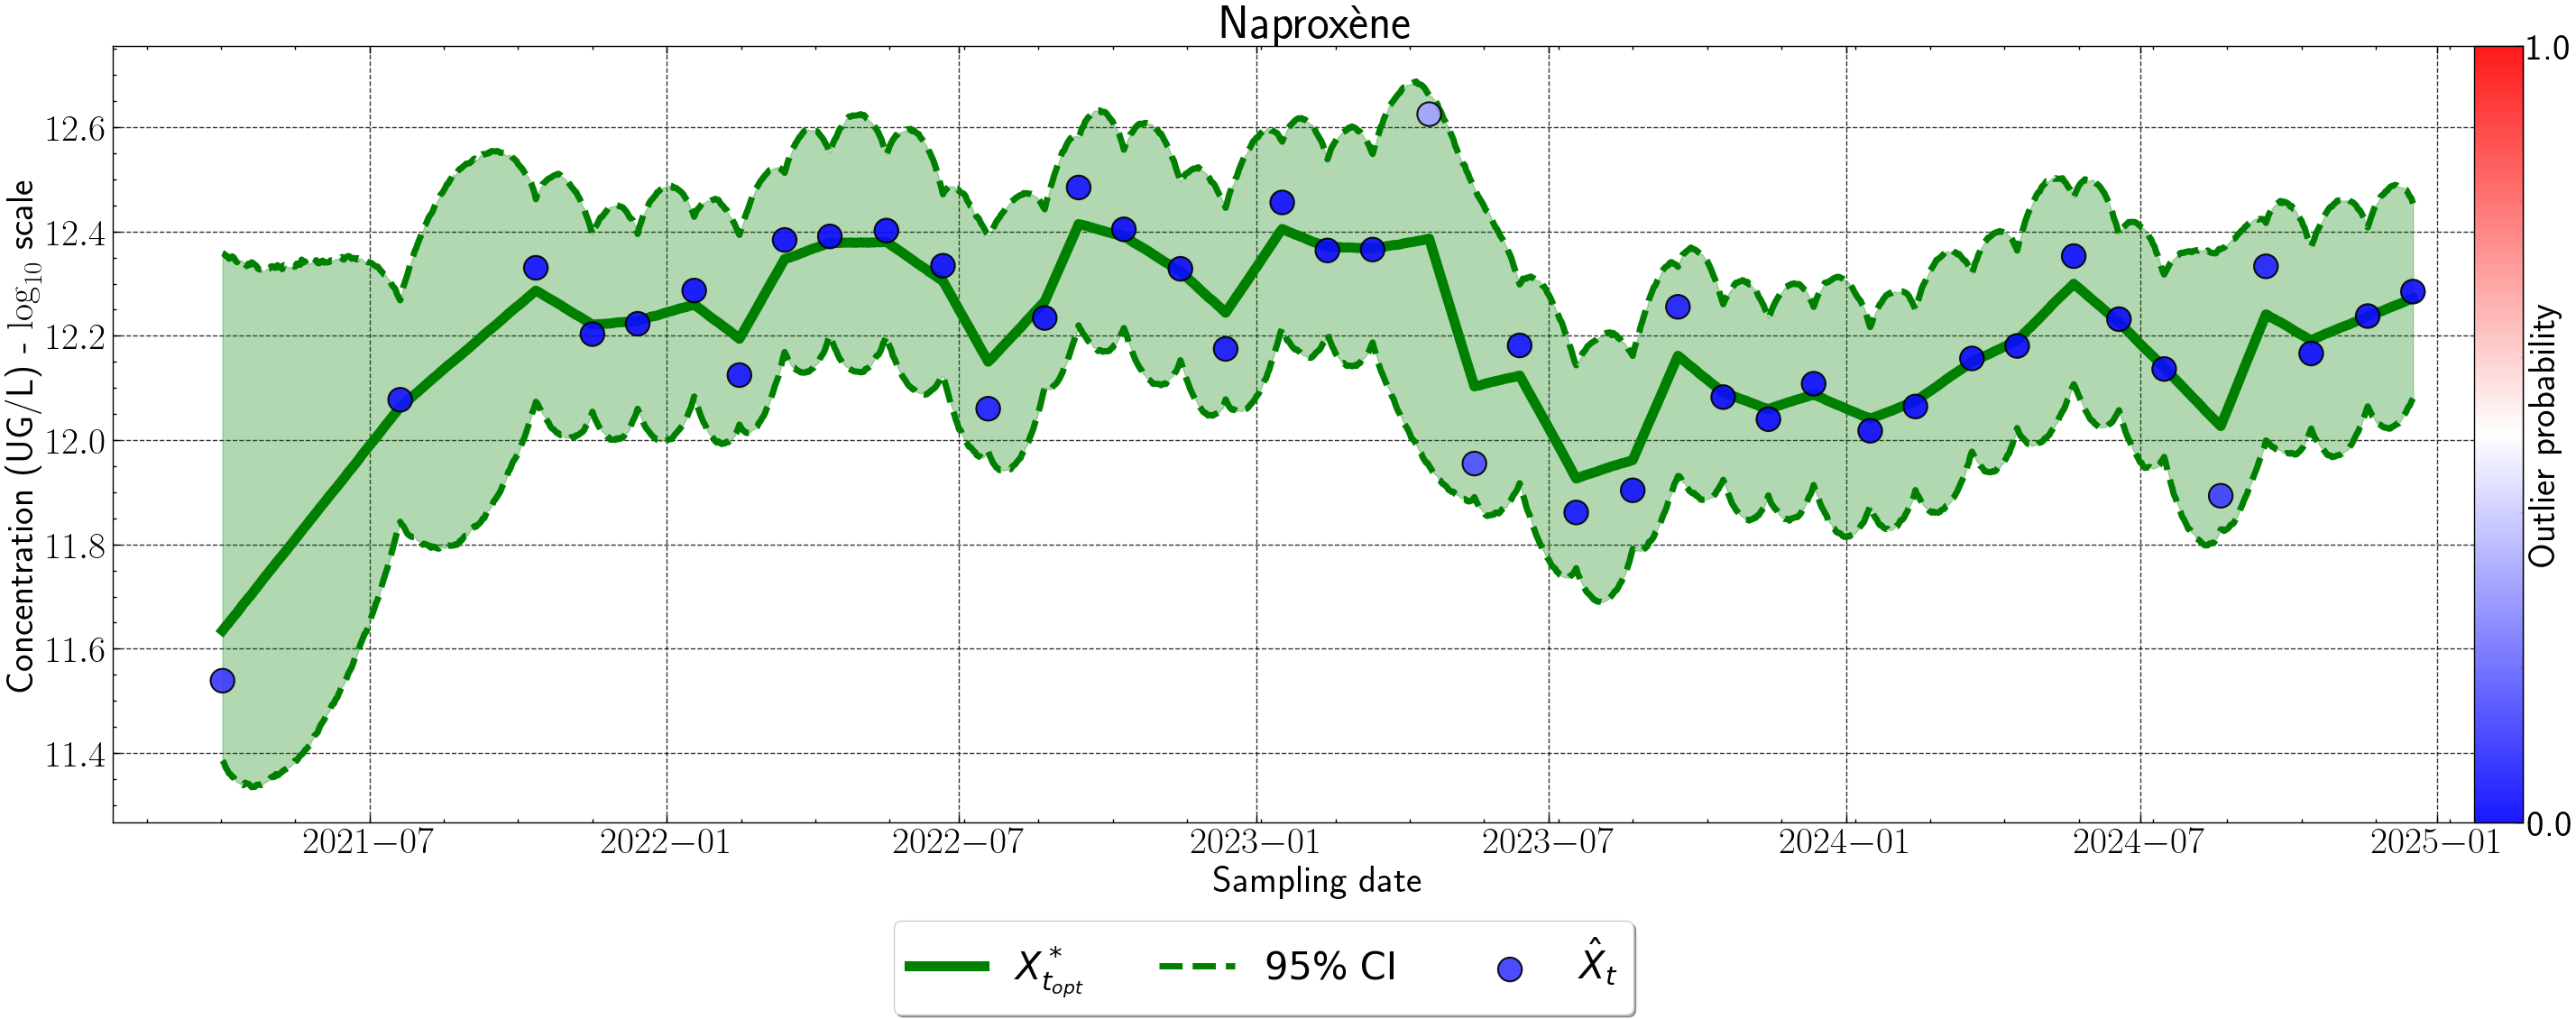

Ofloxacine


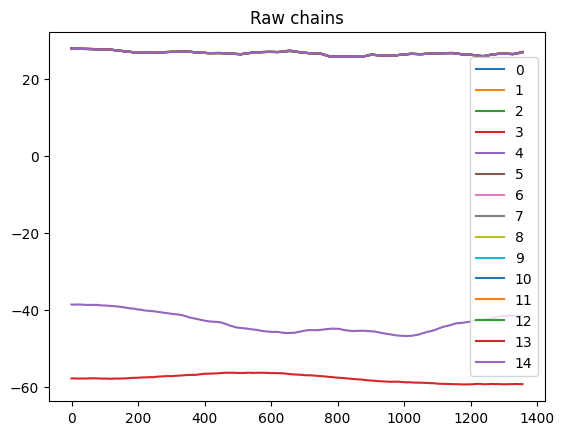

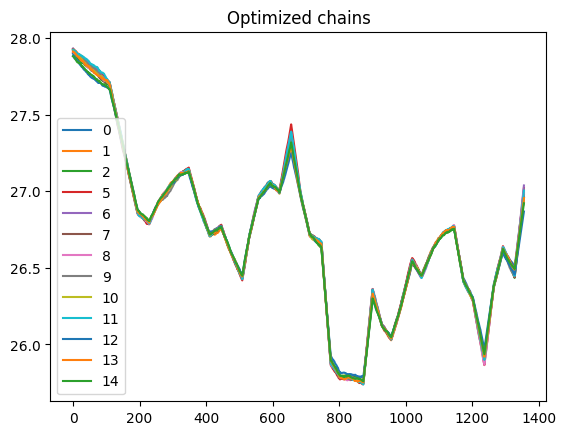

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.091  0.017   0.061    0.124      0.001    0.001     186.0     200.0   
eps    0.259  0.080   0.119    0.408      0.001    0.001    8236.0   15574.0   
p_out  0.099  0.060   0.004    0.208      0.001    0.000    7442.0   16099.0   

       r_hat  
sig     1.06  
eps     1.00  
p_out   1.00  


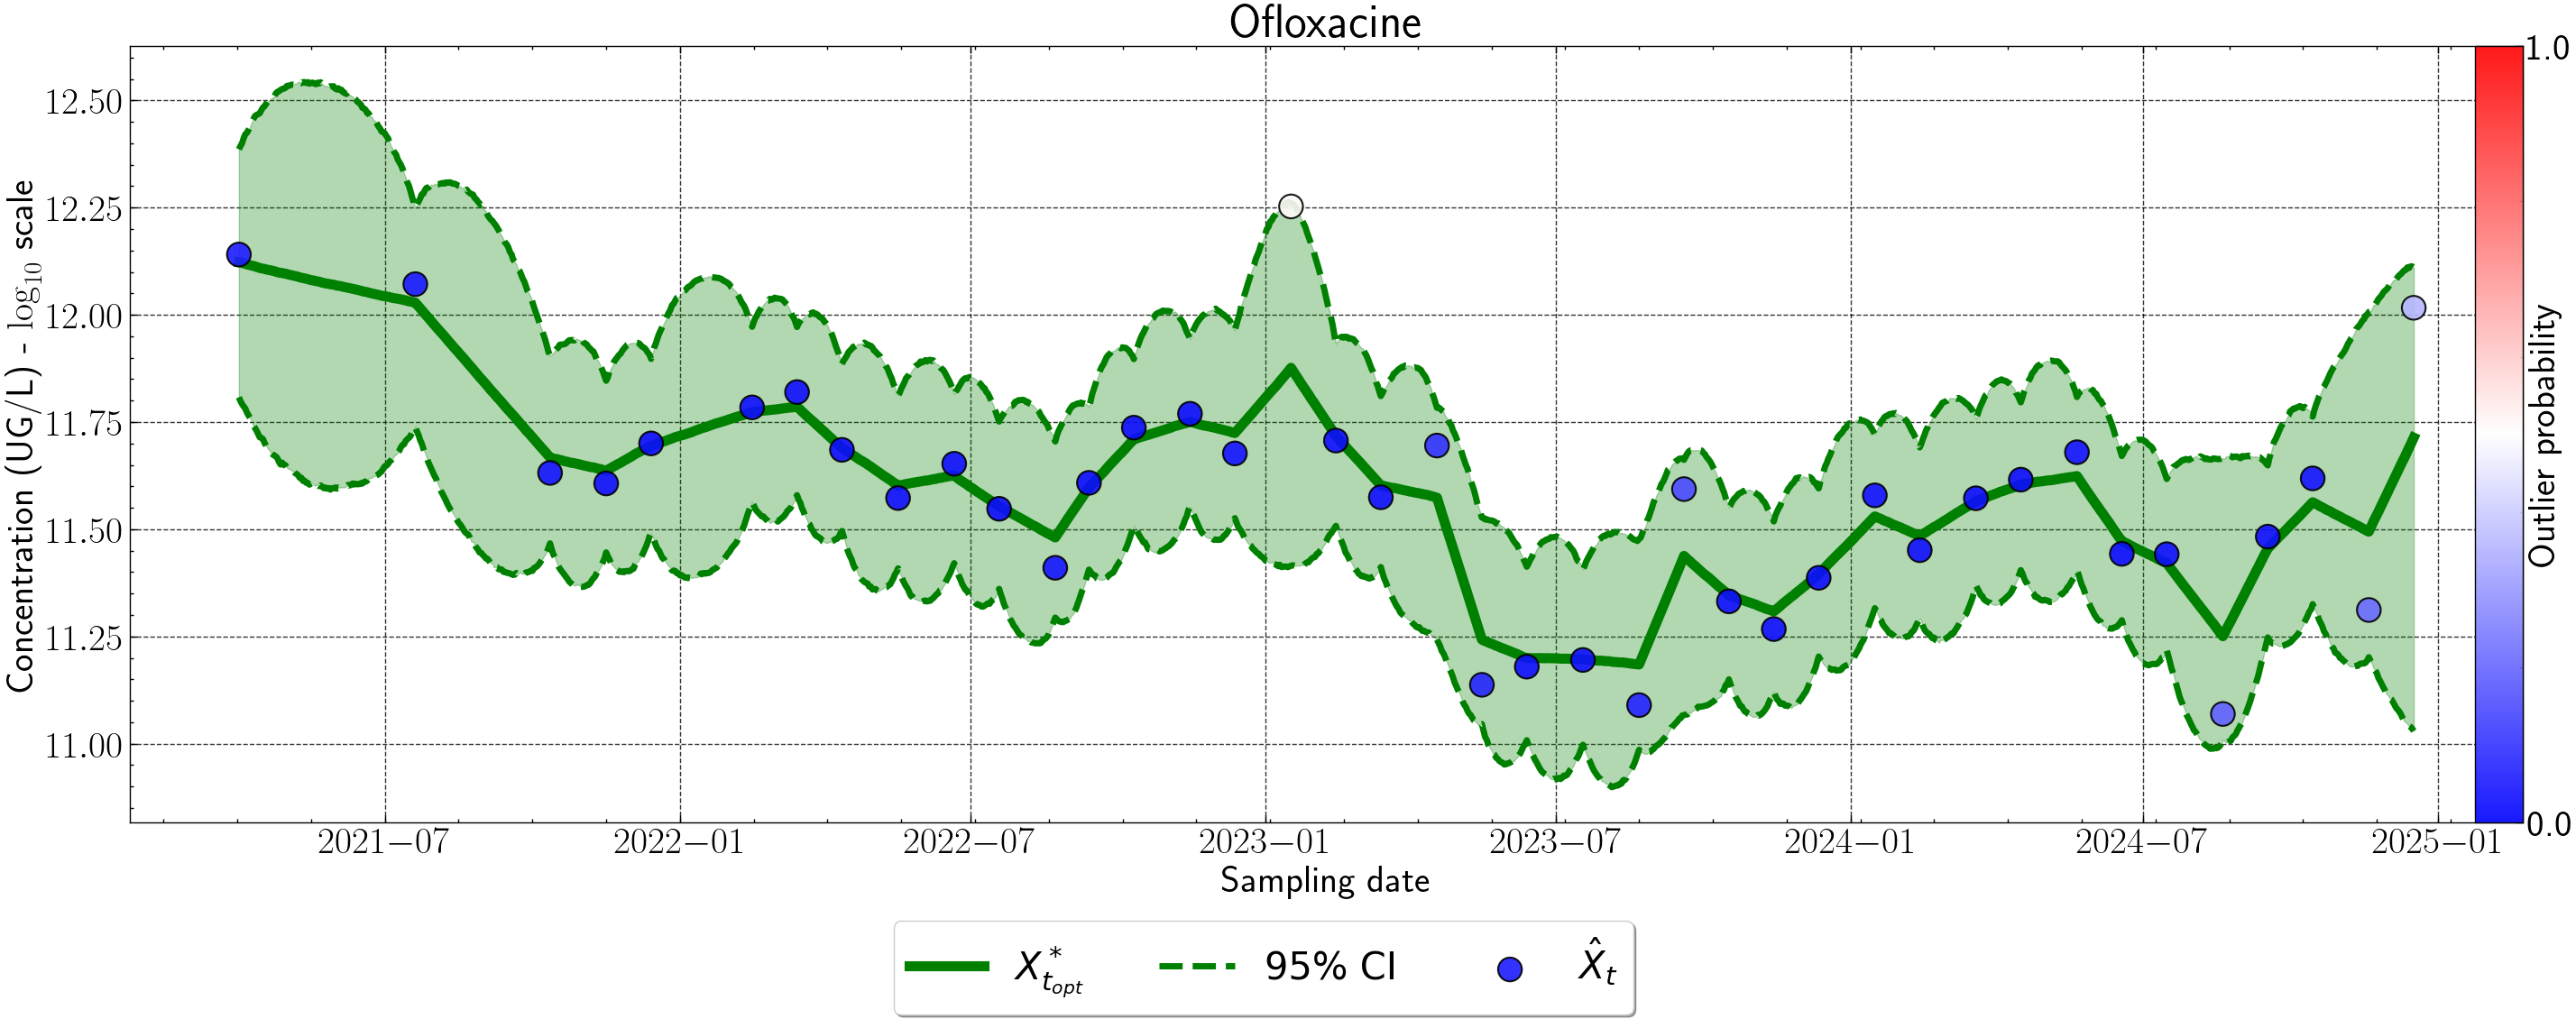

Oxazépam


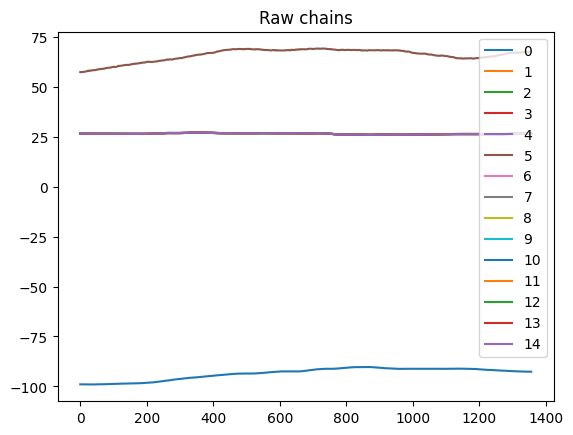

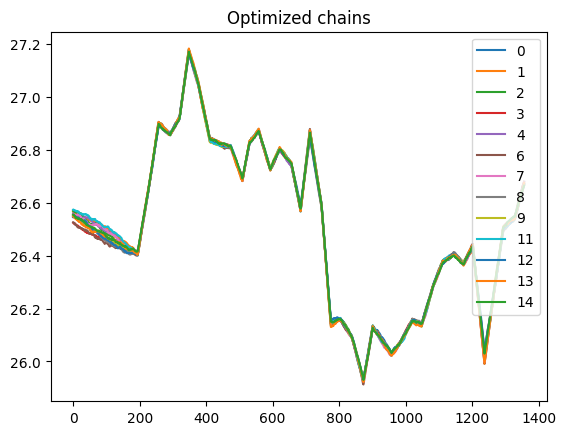

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.061  0.010   0.044    0.081      0.001    0.001     162.0     312.0   
eps    0.169  0.043   0.094    0.249      0.000    0.000   10616.0   16311.0   
p_out  0.072  0.048   0.004    0.160      0.000    0.000   17882.0   14891.0   

       r_hat  
sig     1.06  
eps     1.00  
p_out   1.00  


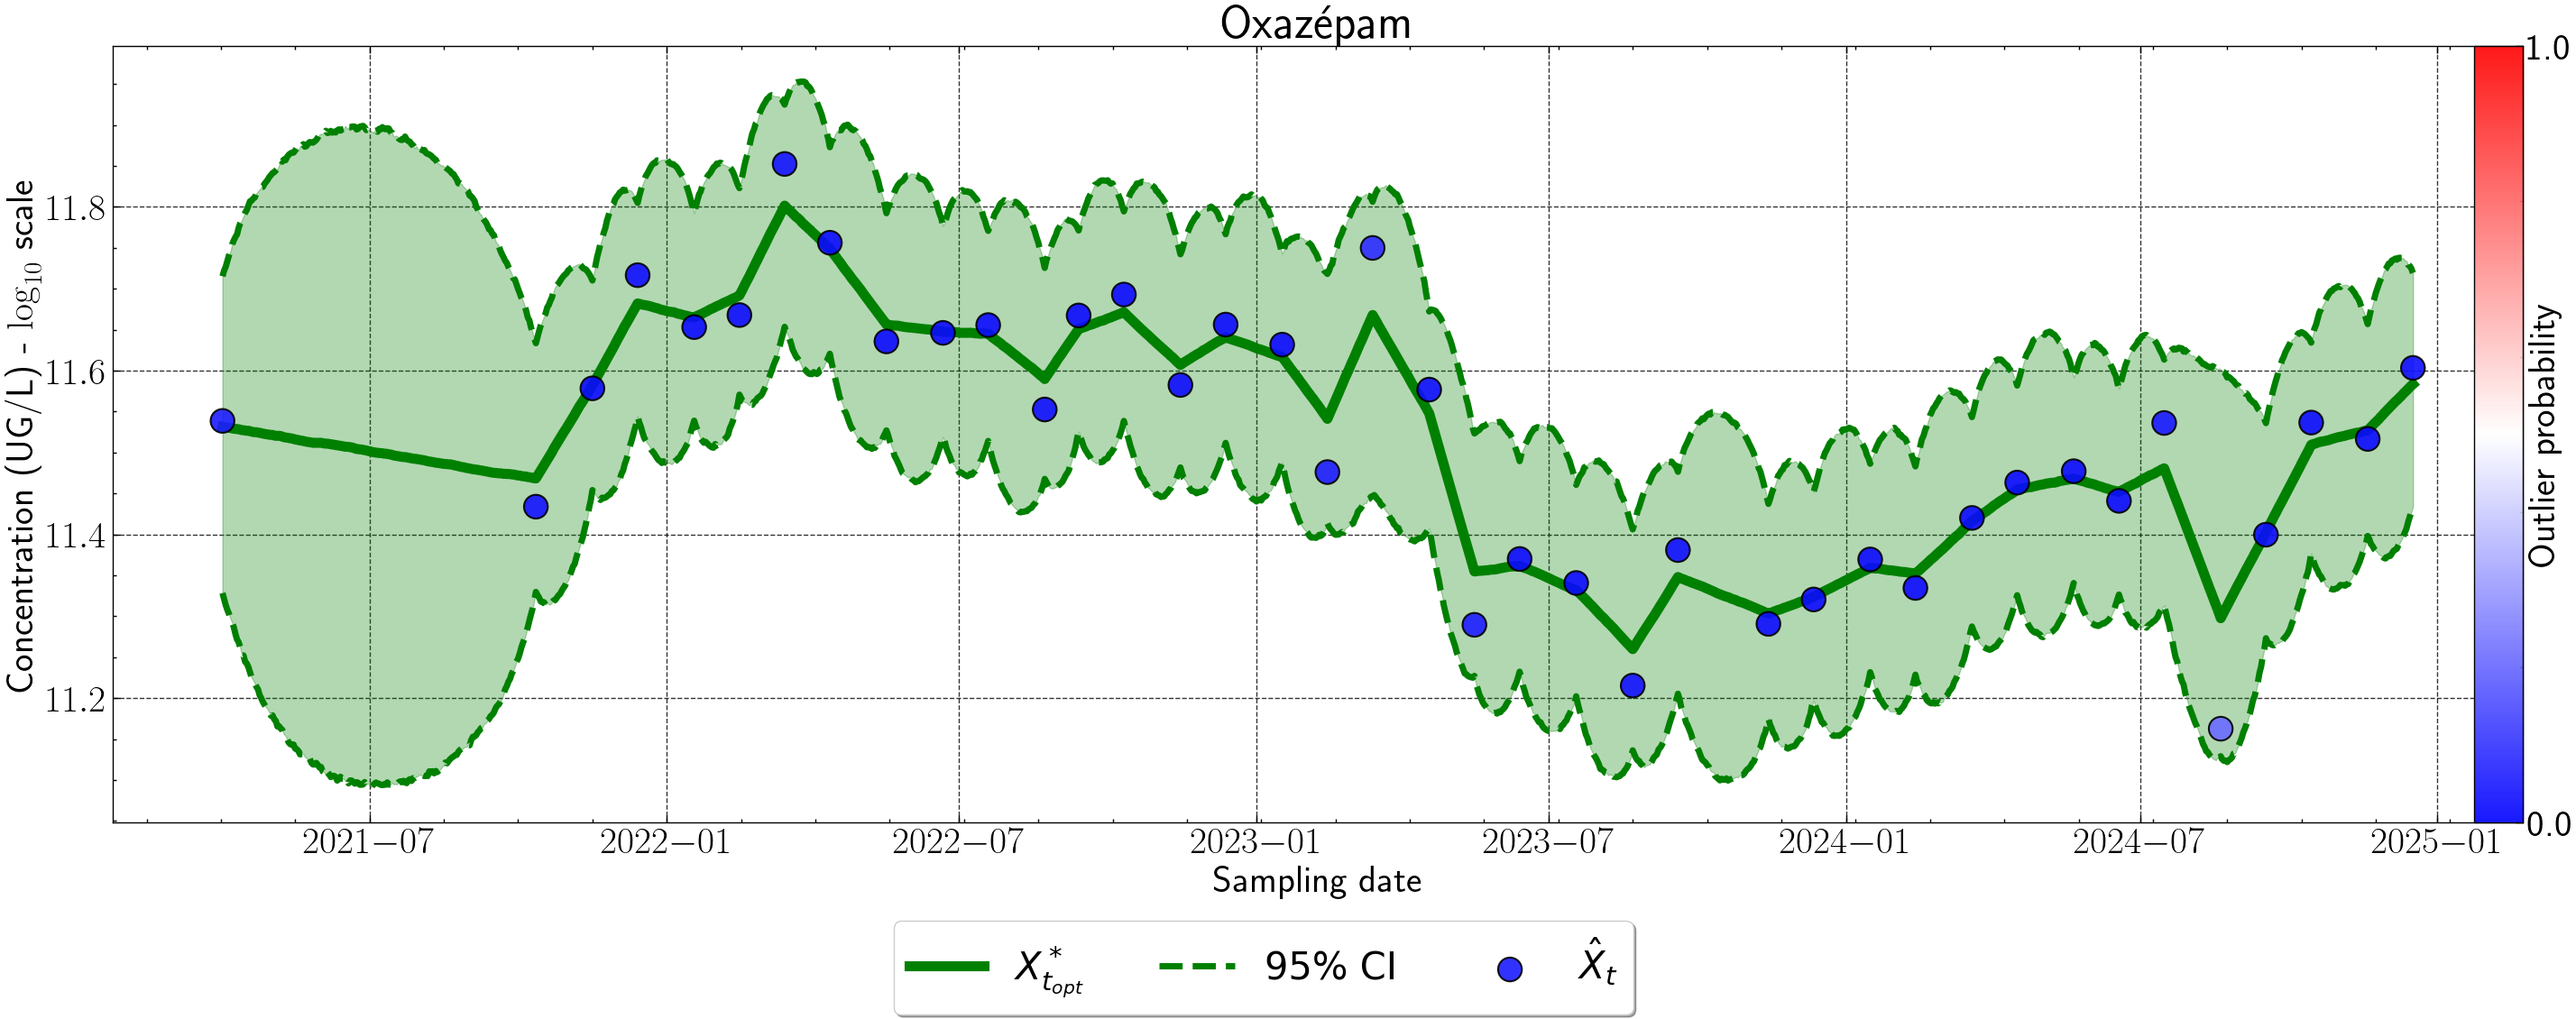

Propranolol


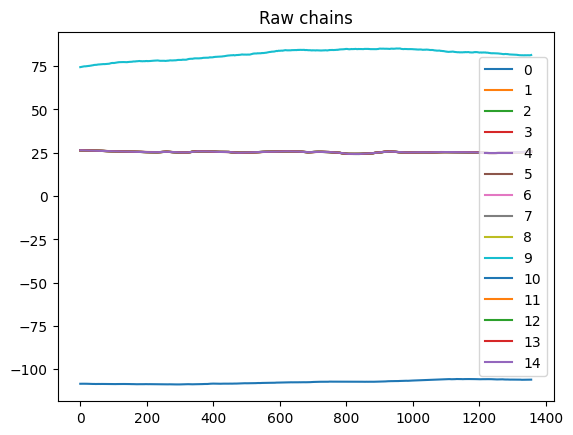

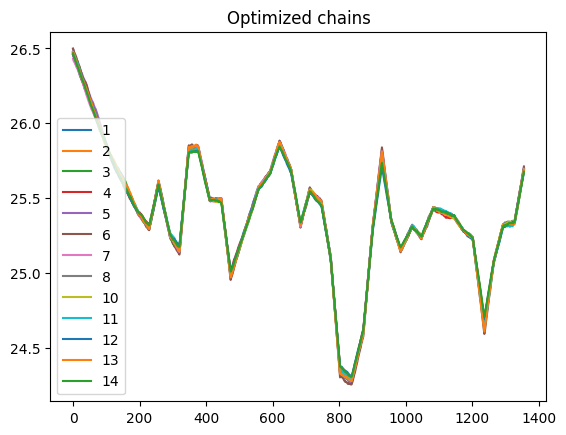

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.095  0.017   0.065    0.127      0.002    0.001     109.0     148.0   
eps    0.250  0.074   0.120    0.388      0.001    0.001    3336.0   13083.0   
p_out  0.078  0.053   0.002    0.175      0.000    0.000   16690.0   16414.0   

       r_hat  
sig     1.08  
eps     1.01  
p_out   1.00  


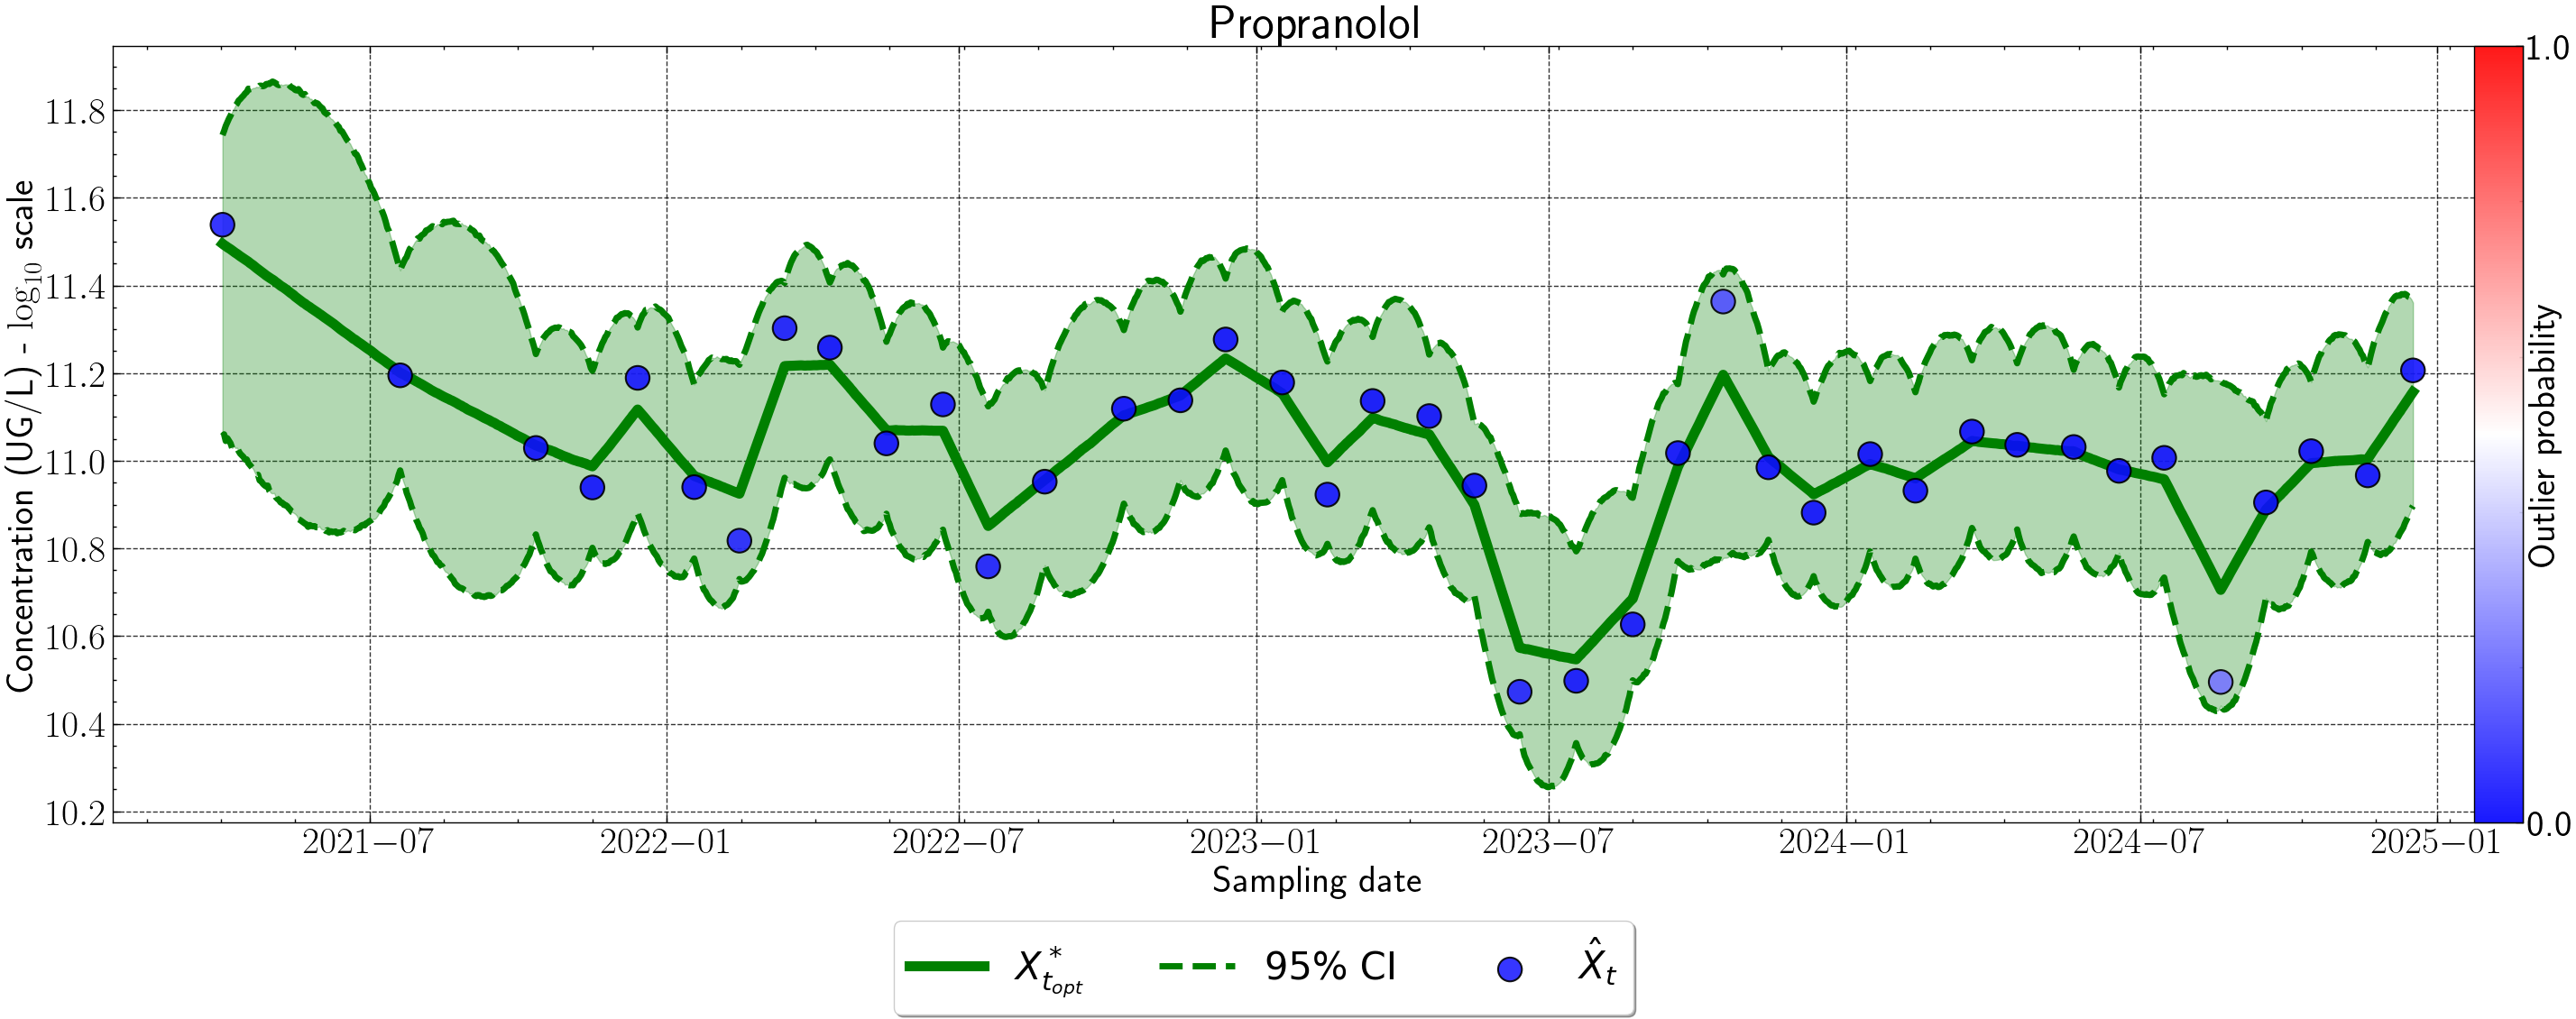

Sotalol


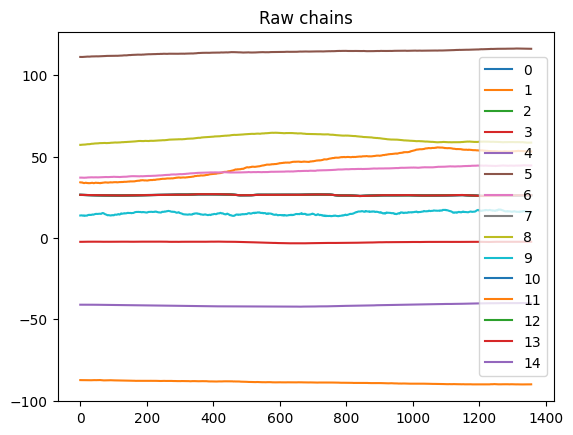

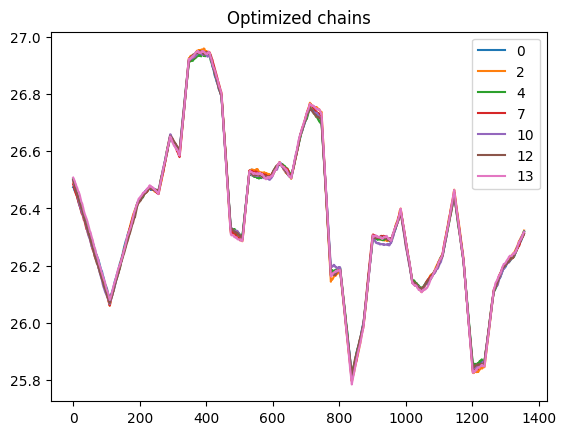

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.068  0.010   0.049    0.087      0.001    0.001     145.0     359.0   
eps    0.197  0.053   0.103    0.297      0.001    0.001    4711.0    8906.0   
p_out  0.089  0.057   0.007    0.197      0.001    0.000    8870.0   10328.0   

       r_hat  
sig     1.05  
eps     1.00  
p_out   1.00  


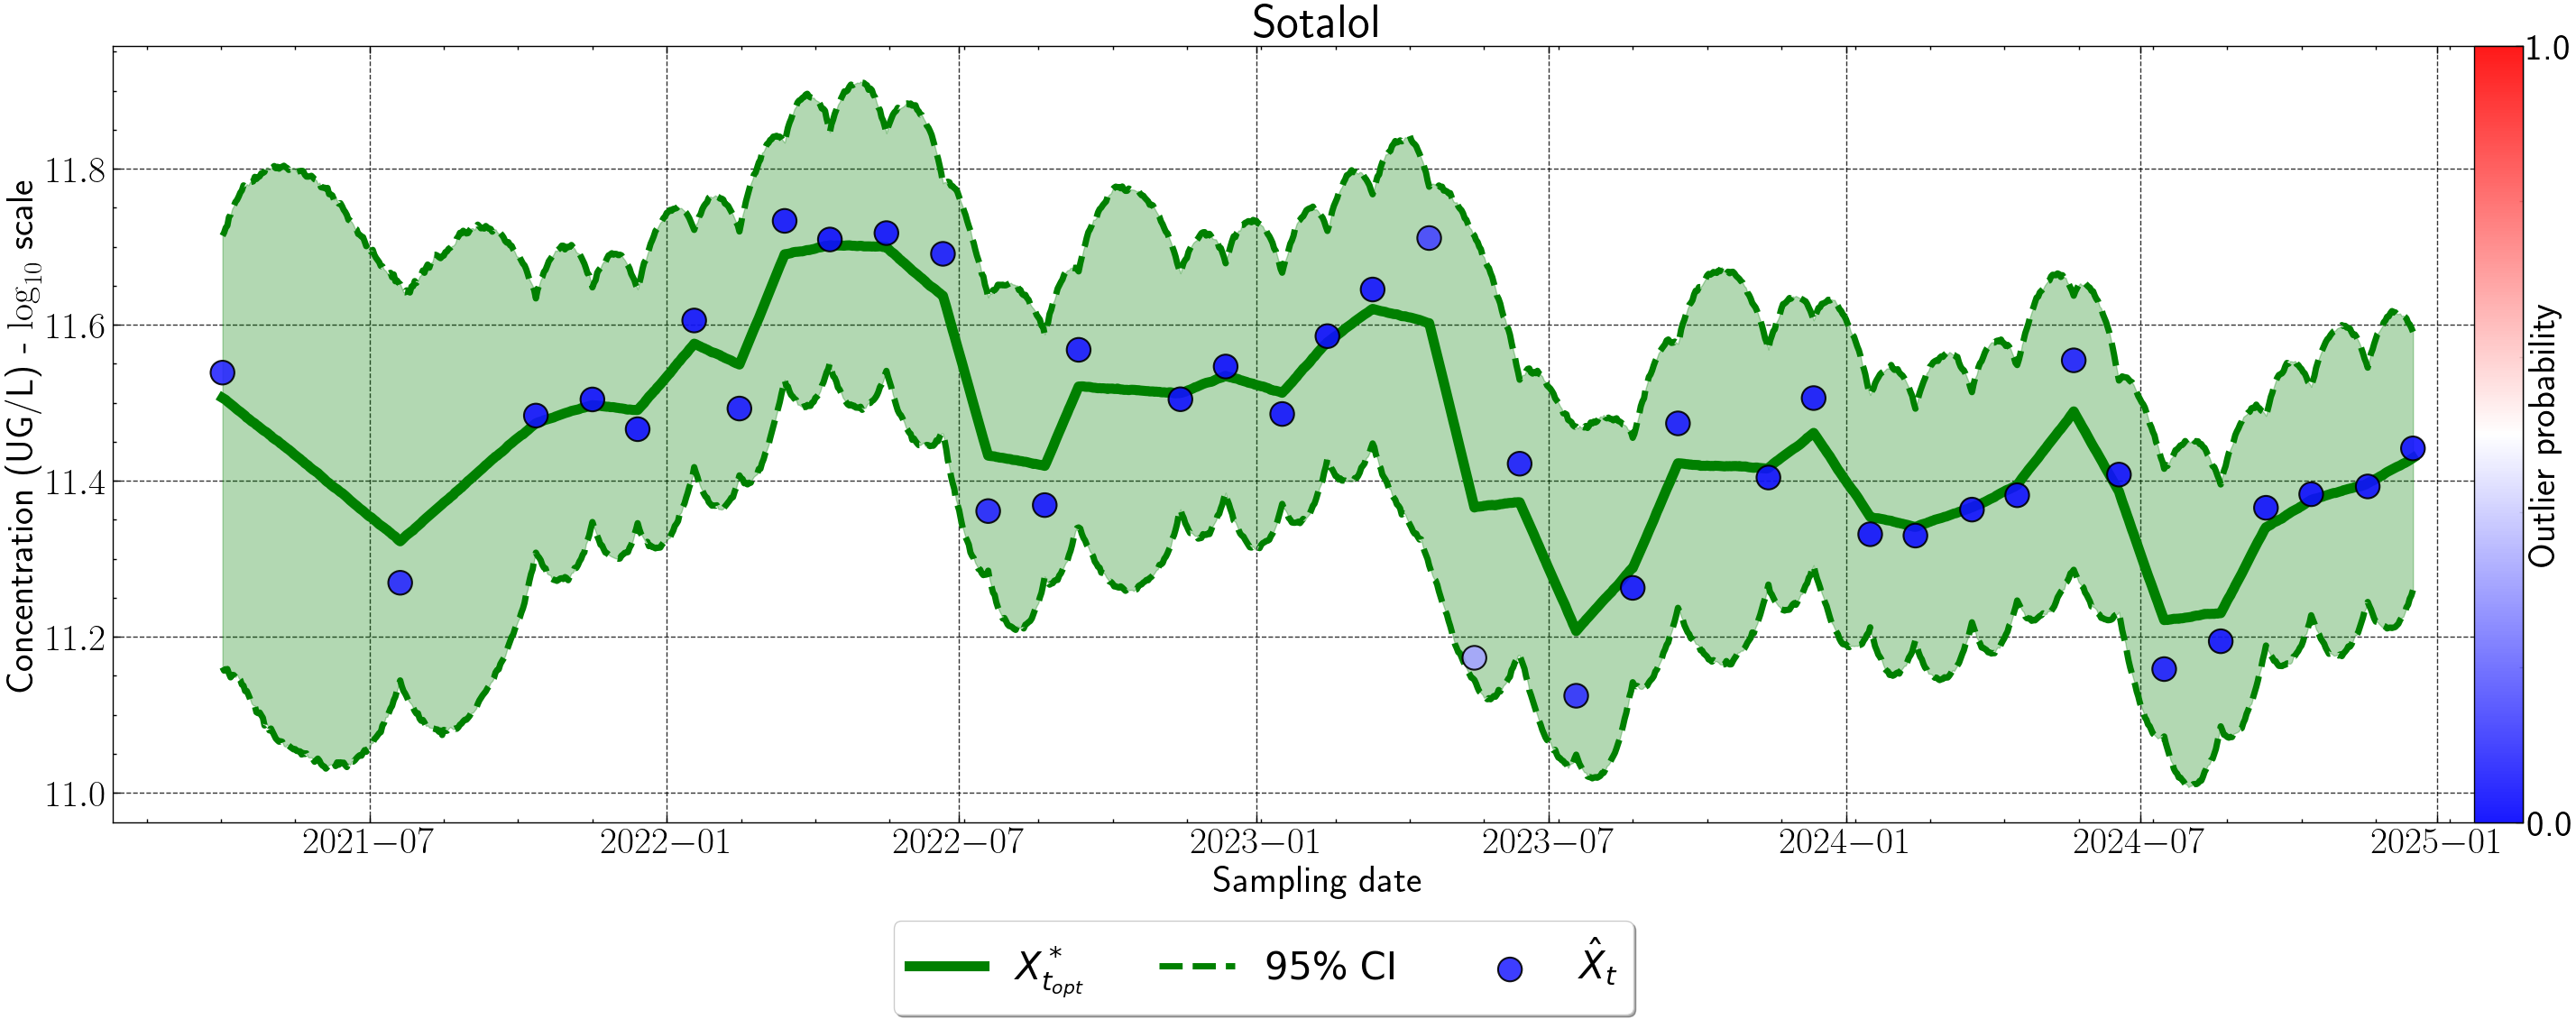

Sulfaméthoxazole


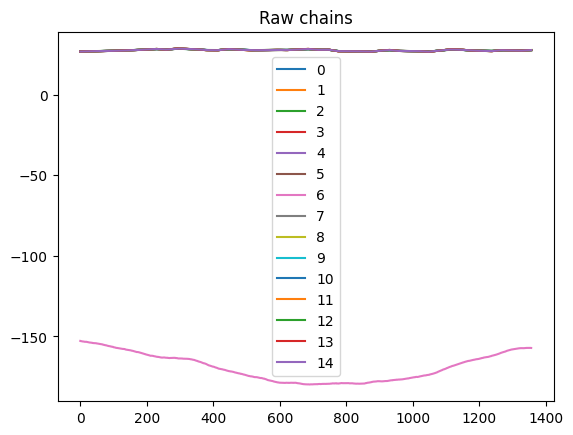

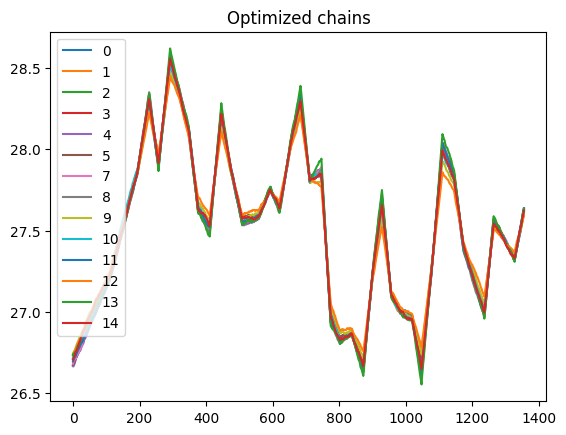

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.119  0.025   0.074    0.163      0.002    0.002     114.0     257.0   
eps    0.386  0.118   0.168    0.604      0.005    0.003     678.0    4675.0   
p_out  0.095  0.064   0.003    0.210      0.000    0.000   19022.0   18608.0   

       r_hat  
sig     1.11  
eps     1.02  
p_out   1.00  


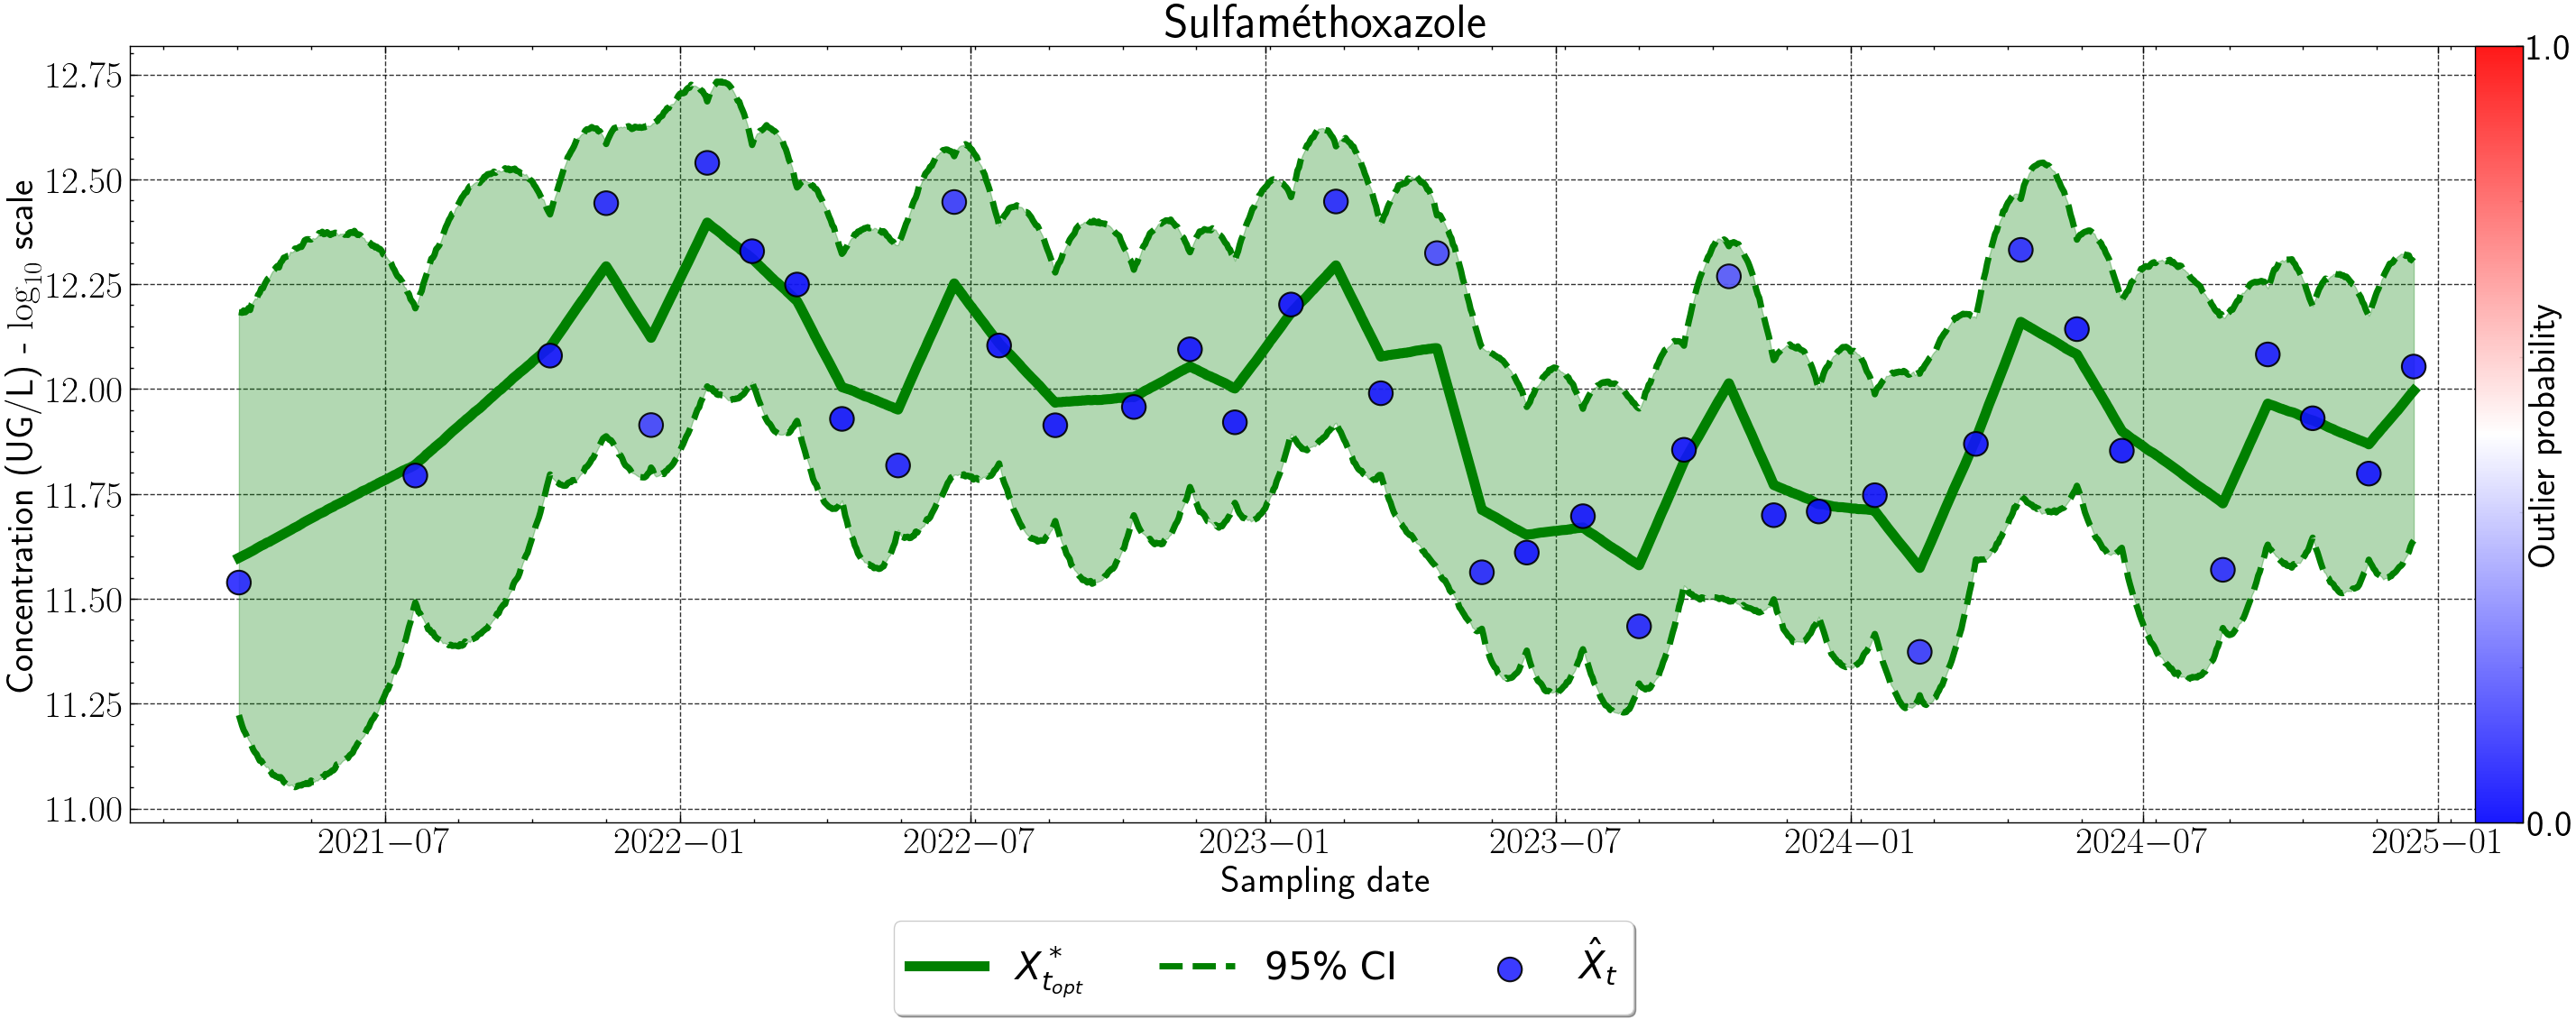

Triméthoprime


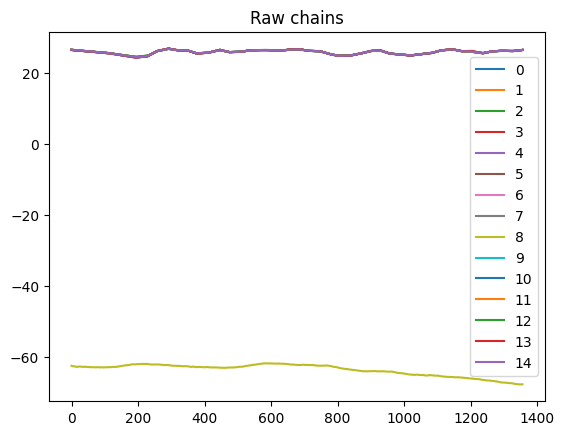

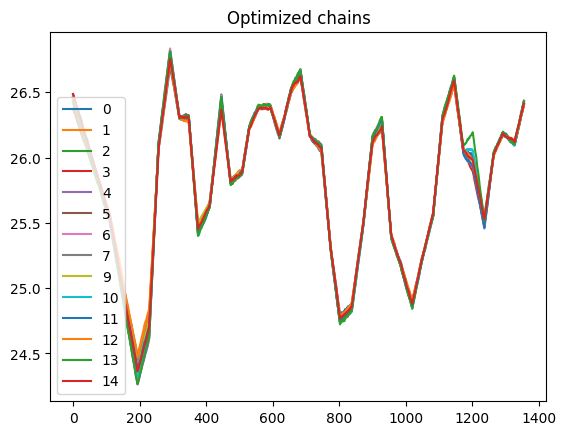

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.134  0.023   0.089    0.177      0.002    0.002     112.0     197.0   
eps    0.319  0.119   0.121    0.540      0.003    0.002    1401.0    3618.0   
p_out  0.096  0.056   0.008    0.196      0.001    0.000   12332.0   15762.0   

       r_hat  
sig     1.10  
eps     1.01  
p_out   1.00  


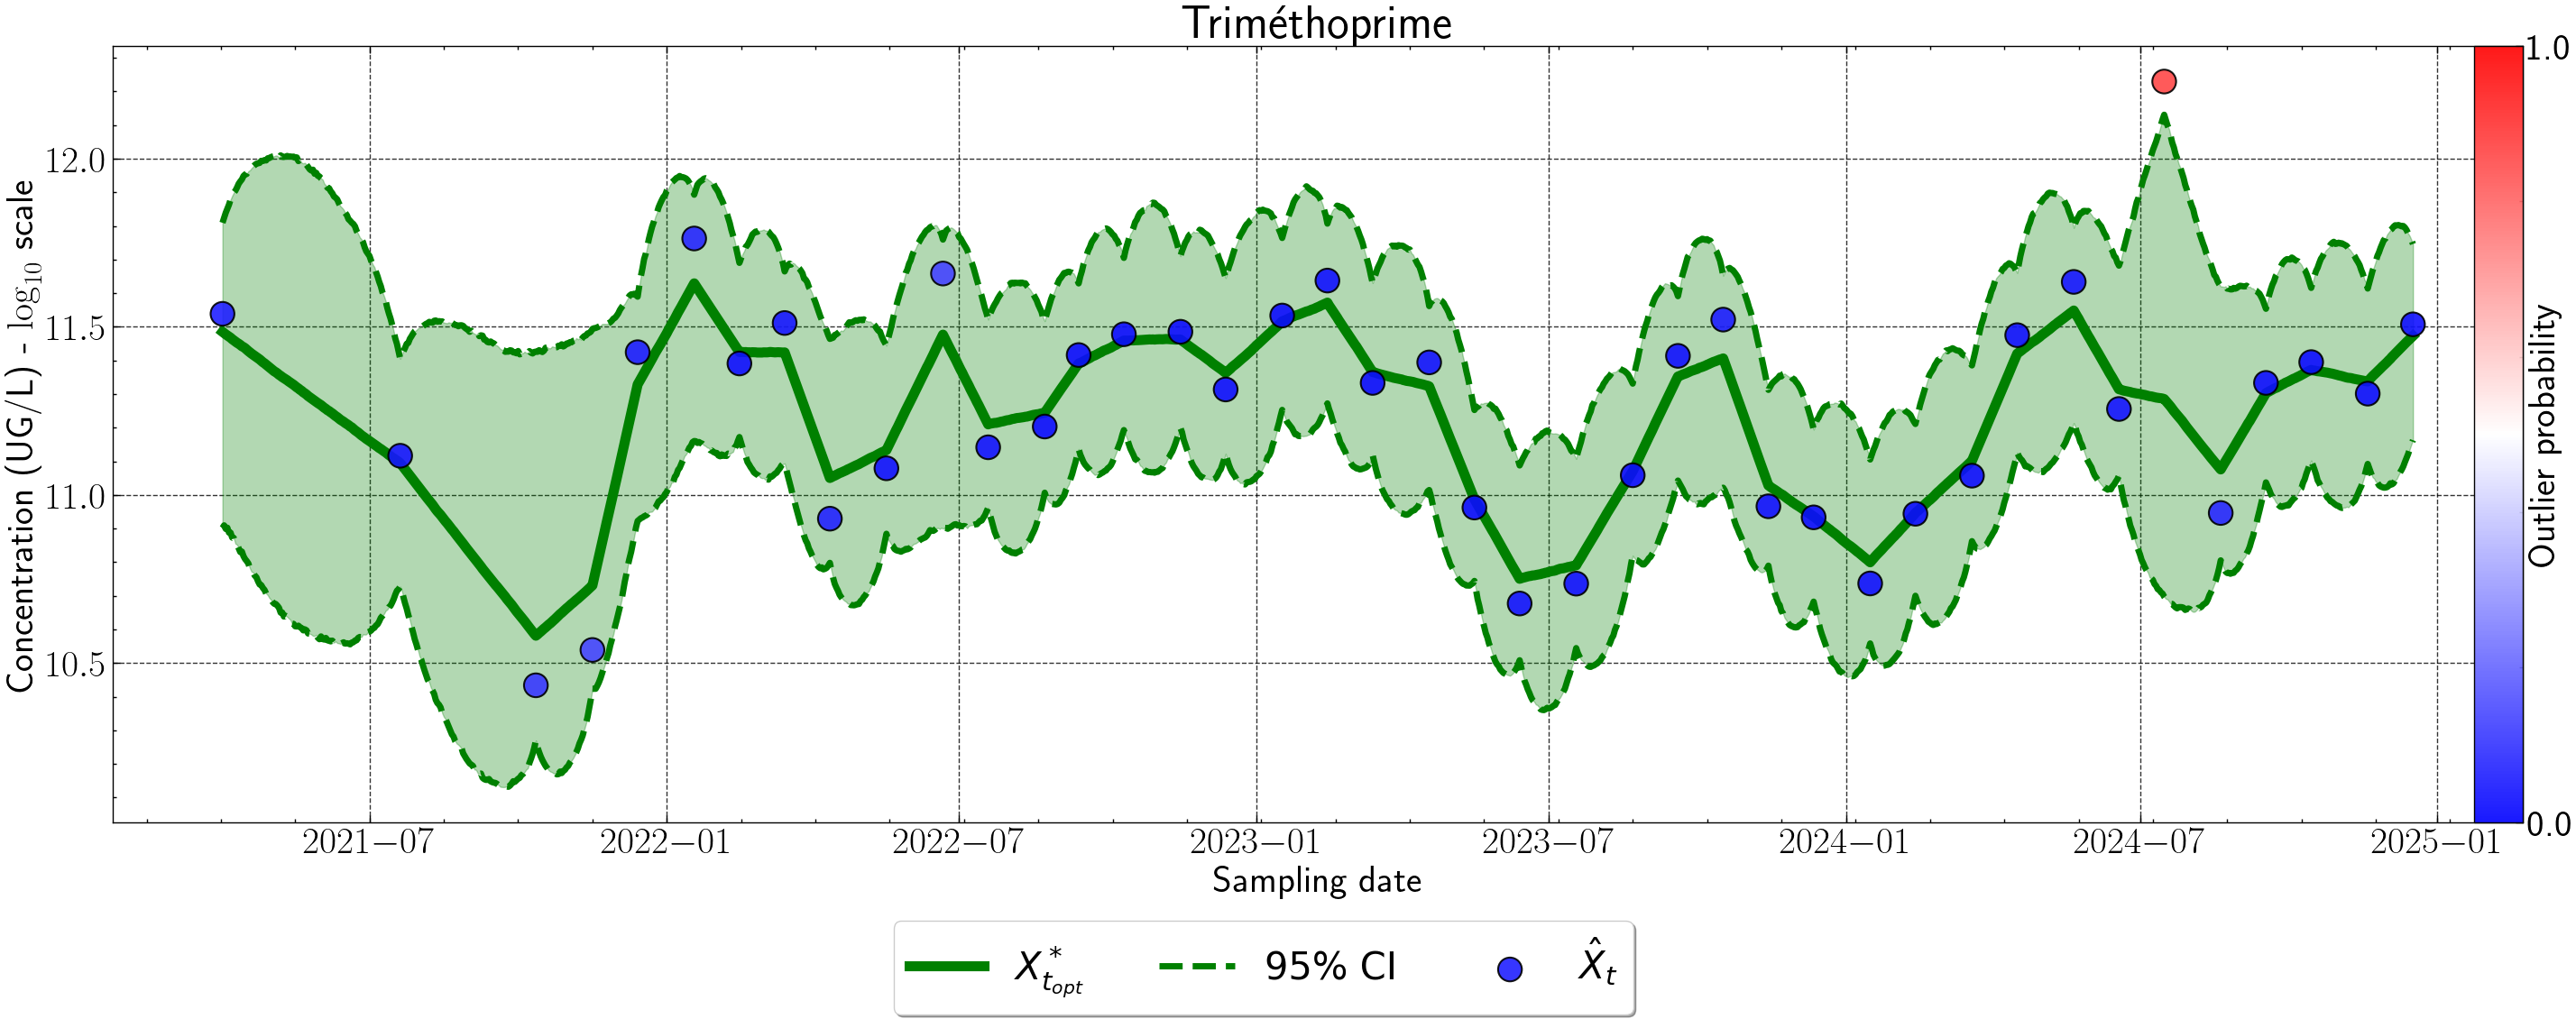

In [11]:
common_flux_data = {}
### Global loop
for this_parameter in viruses_list:

    print("==========")
    print(this_parameter)
    print("==========")
        
    scou = scou_dict[this_parameter]
    sub_data = sub_data_dict[this_parameter]

    selected_chains = np.arange(nb_chains).tolist()
    remove_those = chain_selector_dict[this_parameter]
    for i in remove_those:
        selected_chains.remove(i)
    
    scou.visualize_latents(selected_chains)
    scou.predict(selected_chains)

    sub_data = append_and_process_results(sub_data, this_parameter, scou)
    visualize_results(sub_data, this_parameter)

In [12]:
for parameter in list(common_flux_data.keys()):
    this_file = common_flux_data[parameter]
    this_file.to_csv('../../outputs/files/chemical_data/' + parameter + '.csv', sep=';', index=False)